In [1]:
# Setup -- shared analysis state, reused by every table/figure cell below. No prose in this
# notebook: each cell below produces exactly one thesis table or figure, ready to copy into
# the LaTeX source (tables) or already saved to results/figures/ (figures).
import sys, warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

SRC = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / 'thesis_analysis.py').exists())
sys.path.insert(0, str(SRC))
import thesis_analysis as ta

ta.setup_plots(figsize=(9, 6))
pd.set_option('display.width', 200); pd.set_option('display.max_columns', 50)
warnings.filterwarnings('ignore', category=FutureWarning)

PALETTE, RUN_COLORS, RUN_LABELS = ta.PALETTE, ta.RUN_COLORS, ta.RUN_LABELS
SAMPLES = ta.available_samples()

S = {}
for s in SAMPLES:
    runs = ta.sample_runs(s)
    core = [r for r in runs if r != 'dw']
    core = [r for r in core if len(ta.load_run(r, sample=s)) > 0]
    if 'full' not in core:
        continue
    idx = ta.common_index(*core, sample=s)
    y, preds, meta = ta.aligned_matrix(core, idx, sample=s)
    entry = {
        'runs': runs, 'core': core, 'idx': idx, 'y': y, 'preds': preds, 'meta': meta,
        'correct': {k: (v == y) for k, v in preds.items()},
        'cluster': meta['vote_id'].to_numpy(),
    }
    if 'dw' in runs:
        entry['idx_dw'] = idx.intersection(ta.load_run('dw', sample=s).index)
    S[s] = entry

print('samples loaded:', ', '.join(f'{s} (n={len(S[s]["idx"]):,})' for s in S))

samples loaded: main (n=9,961), random (n=9,967), stratified (n=9,241)


In [2]:
# Table: Full pipeline vs. majority-class baseline (always_yea) across samples
# -> tab:full_vs_always_yea
# Step 1: calculation, kept as a plain pandas DataFrame so the numbers can be checked directly.
METRICS = ['accuracy', 'macro_f1', 'weighted_f1',
           'precision_Yea', 'recall_Yea', 'precision_Nay', 'recall_Nay']
METRIC_LABELS = {
    'accuracy': 'Accuracy', 'macro_f1': 'Macro F1', 'weighted_f1': 'Weighted F1',
    'precision_Yea': 'Precision (Yea)', 'recall_Yea': 'Recall (Yea)',
    'precision_Nay': 'Precision (Nay)', 'recall_Nay': 'Recall (Nay)',
}

rows = []
for s in SAMPLES:
    t = ta.metrics_table(S[s]['y'], S[s]['preds'])
    for method in ['full', 'always_yea']:
        for m in METRICS:
            rows.append({'sample': s, 'method': method, 'metric': m, 'value': t.loc[method, m]})
        rows.append({'sample': s, 'method': method, 'metric': 'n', 'value': len(S[s]['idx'])})

FVA_LONG = pd.DataFrame(rows)
FVA_TABLE = FVA_LONG.pivot_table(index='metric', columns=['sample', 'method'], values='value',
                                 sort=False)
FVA_TABLE = FVA_TABLE.reindex(METRICS + ['n'])
FVA_TABLE

sample                main                    random                stratified             
method                full   always_yea         full   always_yea         full   always_yea
metric                                                                                     
accuracy          0.869391     0.732758     0.831544     0.701816     0.868196     0.727410
macro_f1          0.813820     0.422885     0.767807     0.412392     0.813607     0.421099
weighted_f1       0.861170     0.619745     0.816910     0.578847     0.859485     0.612623
precision_Yea     0.870064     0.732758     0.824384     0.701816     0.865957     0.727410
recall_Yea        0.966023     1.000000     0.965690     1.000000     0.968759     1.000000
precision_Nay     0.866451     0.000000     0.864636     0.000000     0.877978     0.000000
recall_Nay        0.604433     0.000000     0.515814     0.000000     0.599841     0.000000
n              9961.000000  9961.000000  9967.000000  9967.000000  9241.000000  9241.000000

In [3]:
# Step 2: format FVA_TABLE (computed above, unmodified) as the LaTeX table.
SAMPLE_DISPLAY = {'main': 'Main', 'random': 'Random', 'stratified': 'Stratified'}

col_header = ' & '.join(
    f'\\multicolumn{{2}}{{c}}{{\\textbf{{{SAMPLE_DISPLAY.get(s, s)}}}}}' for s in SAMPLES)
cmid = ' '.join(f'\\cmidrule(lr){{{2+2*i}-{3+2*i}}}' for i in range(len(SAMPLES)))

lines = []
lines.append('\\begin{table}[htbp]')
lines.append('\\centering')
lines.append('\\begin{tabular}{l' + 'rr' * len(SAMPLES) + '}')
lines.append('\\toprule')
lines.append(' & ' + col_header + ' \\\\')
lines.append(cmid)
lines.append('\\textbf{Metric} & ' + ' & '.join('Full & Always-yea' for _ in SAMPLES) + ' \\\\')
lines.append('\\midrule')
for m in METRICS:
    vals = [f'{FVA_TABLE.loc[m, (s, method)]:.4f}' for s in SAMPLES for method in ['full', 'always_yea']]
    lines.append(f'{METRIC_LABELS[m]:<17} & ' + ' & '.join(vals) + ' \\\\')
lines.append('\\midrule')
n_vals = [f"\\multicolumn{{2}}{{c}}{{{int(FVA_TABLE.loc['n', (s, 'full')]):,}}}" for s in SAMPLES]
lines.append('$n$ & ' + ' & '.join(n_vals).replace(',', '{,}') + ' \\\\')
lines.append('\\bottomrule')
lines.append('\\end{tabular}')
lines.append('\\caption{Full pipeline versus majority-class baseline (\\texttt{always\\_yea}) '
             'across samples.}')
lines.append('\\label{tab:full_vs_always_yea}')
lines.append('\\end{table}')

print('\n'.join(lines))

\begin{table}[htbp]
\centering
\begin{tabular}{lrrrrrr}
\toprule
 & \multicolumn{2}{c}{\textbf{Main}} & \multicolumn{2}{c}{\textbf{Random}} & \multicolumn{2}{c}{\textbf{Stratified}} \\
\cmidrule(lr){2-3} \cmidrule(lr){4-5} \cmidrule(lr){6-7}
\textbf{Metric} & Full & Always-yea & Full & Always-yea & Full & Always-yea \\
\midrule
Accuracy          & 0.8694 & 0.7328 & 0.8315 & 0.7018 & 0.8682 & 0.7274 \\
Macro F1          & 0.8138 & 0.4229 & 0.7678 & 0.4124 & 0.8136 & 0.4211 \\
Weighted F1       & 0.8612 & 0.6197 & 0.8169 & 0.5788 & 0.8595 & 0.6126 \\
Precision (Yea)   & 0.8701 & 0.7328 & 0.8244 & 0.7018 & 0.8660 & 0.7274 \\
Recall (Yea)      & 0.9660 & 1.0000 & 0.9657 & 1.0000 & 0.9688 & 1.0000 \\
Precision (Nay)   & 0.8665 & 0.0000 & 0.8646 & 0.0000 & 0.8780 & 0.0000 \\
Recall (Nay)      & 0.6044 & 0.0000 & 0.5158 & 0.0000 & 0.5998 & 0.0000 \\
\midrule
$n$ & \multicolumn{2}{c}{9{,}961} & \multicolumn{2}{c}{9{,}967} & \multicolumn{2}{c}{9{,}241} \\
\bottomrule
\end{tabular}
\caption{Full

In [4]:
# Table: Full pipeline vs. DW-NOMINATE across samples, on DW's own scorable subset
# -> tab:full_vs_dw
# Step 1: calculation, kept as a plain pandas DataFrame so the numbers can be checked directly.
DW_METRICS = ['accuracy', 'macro_f1', 'precision_Yea', 'recall_Yea', 'precision_Nay', 'recall_Nay']
DW_METRIC_LABELS = {
    'accuracy': 'Accuracy', 'macro_f1': 'Macro F1',
    'precision_Yea': 'Precision (Yea)', 'recall_Yea': 'Recall (Yea)',
    'precision_Nay': 'Precision (Nay)', 'recall_Nay': 'Recall (Nay)',
}

rows = []
FVD_SIG = {}
for s in SAMPLES:
    e = S[s]
    if 'idx_dw' not in e:
        continue
    dw_runs = e['core'] + ['dw']
    y2, preds2, meta2 = ta.aligned_matrix(dw_runs, e['idx_dw'], sample=s)
    corr2 = {k: (v == y2) for k, v in preds2.items()}
    t2 = ta.metrics_table(y2, preds2)
    n = len(e['idx_dw'])

    for method in ['full', 'dw']:
        for m in DW_METRICS:
            rows.append({'sample': s, 'method': method, 'metric': m, 'value': t2.loc[method, m]})
        rows.append({'sample': s, 'method': method, 'metric': 'n', 'value': n})

    FVD_SIG[s] = ta.pairwise_mcnemar(
        {k: v for k, v in corr2.items() if k in ('full', 'dw')},
        [('full', 'dw')], cluster=meta2['vote_id'].to_numpy(), B=10_000,
    ).iloc[0]

FVD_TABLE = pd.DataFrame(rows).pivot_table(index='metric', columns=['sample', 'method'],
                                           values='value', sort=False)
FVD_TABLE = FVD_TABLE.reindex(DW_METRICS + ['n'])
FVD_TABLE

sample                main                    random                stratified             
method                full           dw         full           dw         full           dw
metric                                                                                     
accuracy          0.857192     0.822886     0.784002     0.791947     0.840297     0.831604
macro_f1          0.811744     0.804959     0.748974     0.779639     0.806104     0.821599
precision_Yea     0.849268     0.929445     0.751793     0.812686     0.818132     0.909959
recall_Yea        0.966825     0.807321     0.958733     0.851662     0.969789     0.822184
precision_Nay     0.887721     0.659150     0.891750     0.756232     0.914582     0.720204
recall_Nay        0.604520     0.858757     0.517839     0.700985     0.600080     0.849079
n              8774.000000  8774.000000  7426.000000  7426.000000  7132.000000  7132.000000

In [5]:
# Step 2: format FVD_TABLE and FVD_SIG (computed above, unmodified) as the LaTeX table.
SAMPLE_DISPLAY = {'main': 'Main', 'random': 'Random', 'stratified': 'Stratified'}

col_header = ' & '.join(
    f'\\multicolumn{{2}}{{c}}{{\\textbf{{{SAMPLE_DISPLAY.get(s, s)}}}}}' for s in SAMPLES)
cmid = ' '.join(f'\\cmidrule(lr){{{2+2*i}-{3+2*i}}}' for i in range(len(SAMPLES)))

lines = []
lines.append('\\begin{table}[htbp]')
lines.append('\\centering')
lines.append('\\begin{tabular}{l' + 'rr' * len(SAMPLES) + '}')
lines.append('\\toprule')
lines.append(' & ' + col_header + ' \\\\')
lines.append(cmid)
lines.append('\\textbf{Metric} & ' + ' & '.join('Full & DW' for _ in SAMPLES) + ' \\\\')
lines.append('\\midrule')
for m in DW_METRICS:
    vals = [f'{FVD_TABLE.loc[m, (s, method)]:.4f}' for s in SAMPLES for method in ['full', 'dw']]
    lines.append(f'{DW_METRIC_LABELS[m]:<13} & ' + ' & '.join(vals) + ' \\\\')
lines.append('\\midrule')

delta_vals, ci_vals, p_vals = [], [], []
for s in SAMPLES:
    if s not in FVD_SIG:
        continue
    r = FVD_SIG[s]
    delta_vals.append(f"\\multicolumn{{2}}{{c}}{{${r['delta_acc']*100:+.2f}$}}")
    ci_vals.append(f"\\multicolumn{{2}}{{c}}{{[${r['delta_ci_low']*100:+.2f}$, "
                   f"${r['delta_ci_high']*100:+.2f}$]}}")
    p_str = '$<0.001$ ($^{***}$)' if r['p_holm'] < 0.001 else f"${r['p_holm']:.3f}$"
    p_vals.append(f'\\multicolumn{{2}}{{c}}{{{p_str}}}')
lines.append('$\\Delta$ (Full $-$ DW), pp & ' + ' & '.join(delta_vals) + ' \\\\')
lines.append('95\\% CI (pp)               & ' + ' & '.join(ci_vals) + ' \\\\')
lines.append('$p$ (Holm)                 & ' + ' & '.join(p_vals) + ' \\\\')
lines.append('\\midrule')
n_vals = [f"\\multicolumn{{2}}{{c}}{{{int(FVD_TABLE.loc['n', (s, 'full')]):,}}}" for s in SAMPLES]
lines.append('$n$ & ' + ' & '.join(n_vals).replace(',', '{,}') + ' \\\\')
lines.append('\\bottomrule')
lines.append('\\end{tabular}')
lines.append('\\caption{Full pipeline versus DW-NOMINATE baseline across samples, on the common '
             "evaluable set intersected with DW-NOMINATE's scorable rows. $\\Delta$ is full accuracy "
             'minus DW accuracy; its 95\\% CI is a paired cluster bootstrap (clustered on roll call, '
             '$B=10{,}000$), and $p$ is from a paired McNemar exact test on accuracy, Holm-corrected '
             'within each sample.}')
lines.append('\\label{tab:full_vs_dw}')
lines.append('\\end{table}')

print('\n'.join(lines))

\begin{table}[htbp]
\centering
\begin{tabular}{lrrrrrr}
\toprule
 & \multicolumn{2}{c}{\textbf{Main}} & \multicolumn{2}{c}{\textbf{Random}} & \multicolumn{2}{c}{\textbf{Stratified}} \\
\cmidrule(lr){2-3} \cmidrule(lr){4-5} \cmidrule(lr){6-7}
\textbf{Metric} & Full & DW & Full & DW & Full & DW \\
\midrule
Accuracy      & 0.8572 & 0.8229 & 0.7840 & 0.7919 & 0.8403 & 0.8316 \\
Macro F1      & 0.8117 & 0.8050 & 0.7490 & 0.7796 & 0.8061 & 0.8216 \\
Precision (Yea) & 0.8493 & 0.9294 & 0.7518 & 0.8127 & 0.8181 & 0.9100 \\
Recall (Yea)  & 0.9668 & 0.8073 & 0.9587 & 0.8517 & 0.9698 & 0.8222 \\
Precision (Nay) & 0.8877 & 0.6592 & 0.8917 & 0.7562 & 0.9146 & 0.7202 \\
Recall (Nay)  & 0.6045 & 0.8588 & 0.5178 & 0.7010 & 0.6001 & 0.8491 \\
\midrule
$\Delta$ (Full $-$ DW), pp & \multicolumn{2}{c}{$+3.43$} & \multicolumn{2}{c}{$-0.79$} & \multicolumn{2}{c}{$+0.87$} \\
95\% CI (pp)               & \multicolumn{2}{c}{[$+1.02$, $+5.88$]} & \multicolumn{2}{c}{[$-2.38$, $+0.75$]} & \multicolumn{2}{c}{[$-1.

In [6]:
# Table: RQ2 comparative -- full pipeline vs. DW-NOMINATE, freshman-only rows, on DW's own
# scorable subset. -> tab:rq2_comparative
# Step 1: calculation, kept as a plain pandas DataFrame so the numbers can be checked directly.
RQ2_ROWS = []
for s in SAMPLES:
    e = S[s]
    if 'idx_dw' not in e:
        continue
    dw_runs = e['core'] + ['dw']
    y2, preds2, meta2 = ta.aligned_matrix(dw_runs, e['idx_dw'], sample=s)
    fresh_mask = (meta2['freshman'] == 'freshman').to_numpy()
    corr2 = {k: (v == y2) for k, v in preds2.items()}
    n = int(fresh_mask.sum())

    sig = ta.pairwise_mcnemar(
        {k: v[fresh_mask] for k, v in corr2.items() if k in ('full', 'dw')},
        [('full', 'dw')], cluster=meta2['vote_id'].to_numpy()[fresh_mask], B=10_000,
    ).iloc[0]

    RQ2_ROWS.append({
        'sample': s, 'method': 'Full pipeline', 'accuracy': corr2['full'][fresh_mask].mean(), 'n': n,
        'delta_vs_dw_pp': sig['delta_acc'] * 100,
        'ci_low_pp': sig['delta_ci_low'] * 100, 'ci_high_pp': sig['delta_ci_high'] * 100,
        'p_holm': sig['p_holm'], 'sig': sig['sig'],
    })
    RQ2_ROWS.append({
        'sample': s, 'method': 'DW-NOMINATE', 'accuracy': corr2['dw'][fresh_mask].mean(), 'n': n,
        'delta_vs_dw_pp': np.nan, 'ci_low_pp': np.nan, 'ci_high_pp': np.nan,
        'p_holm': np.nan, 'sig': '',
    })

RQ2_COMPARATIVE = pd.DataFrame(RQ2_ROWS)
RQ2_COMPARATIVE

,sample,method,accuracy,n,delta_vs_dw_pp,ci_low_pp,ci_high_pp,p_holm,sig
0,main,Full pipeline,0.883929,1120,6.160714,2.400333,9.982190,0.000046,***
1,main,DW-NOMINATE,0.822321,1120,NaN,NaN,NaN,NaN,
2,random,Full pipeline,0.802483,886,1.805869,-1.639660,5.187781,0.328867,n.s.
3,random,DW-NOMINATE,0.784424,886,NaN,NaN,NaN,NaN,
4,stratified,Full pipeline,0.873362,916,5.567686,1.531520,9.825515,0.001012,**
5,stratified,DW-NOMINATE,0.817686,916,NaN,NaN,NaN,NaN,


In [7]:
# Step 2: format RQ2_COMPARATIVE (computed above, unmodified) as the LaTeX table.
SAMPLE_DISPLAY = {'main': 'Main', 'random': 'Random', 'stratified': 'Stratified'}

def fmt_row(r):
    if pd.isna(r['delta_vs_dw_pp']):
        delta, ci, p = '--', '--', '--'
    else:
        delta = f"${r['delta_vs_dw_pp']:+.2f}$"
        ci = f"[${r['ci_low_pp']:+.2f}$, ${r['ci_high_pp']:+.2f}$]"
        stars = {'***': ' ($^{***}$)', '**': ' ($^{**}$)', '*': ' ($^{*}$)', 'n.s.': ' (n.s.)'}.get(r['sig'], '')
        p_str = '$<0.001$' if r['p_holm'] < 0.001 else f"${r['p_holm']:.3f}$"
        p = p_str + stars
    return f"  & {r['method']:<14} & {r['accuracy']:.4f} & {r['n']:>4} & {delta:>8} & {ci:<22} & {p} \\\\"

lines = []
lines.append('\\begin{table}[htbp]')
lines.append('\\centering')
lines.append('\\small')
lines.append('\\begin{tabular}{llrrrrr}')
lines.append('\\toprule')
lines.append('Sample & Method & Accuracy & $n$ & $\\Delta$ vs.\\ DW (pp) & 95\\% CI (pp) & $p$ (Holm) \\\\')
lines.append('\\midrule')
for i, s in enumerate(SAMPLES):
    if s not in RQ2_COMPARATIVE['sample'].values:
        continue
    sub = RQ2_COMPARATIVE[RQ2_COMPARATIVE['sample'] == s]
    lines.append(f'\\multirow{{{len(sub)}}}{{*}}{{{SAMPLE_DISPLAY.get(s, s)}}}')
    for _, r in sub.iterrows():
        lines.append(fmt_row(r))
    if i < len(SAMPLES) - 1:
        lines.append('\\addlinespace')
lines.append('\\bottomrule')
lines.append('\\end{tabular}')
lines.append('\\caption{Comparative test for RQ2: full pipeline against DW-NOMINATE, on '
             'freshman-only rows restricted to DW-NOMINATE\'s own scorable subset. $\\Delta$ is '
             'full pipeline accuracy minus DW-NOMINATE accuracy; its 95\\% CI (paired cluster '
             'bootstrap, clustered on roll call, $B=10{,}000$) and $p$ are from a paired McNemar '
             'exact test, Holm-corrected.}')
lines.append('\\label{tab:rq2_comparative}')
lines.append('\\end{table}')

print('\n'.join(lines))

\begin{table}[htbp]
\centering
\small
\begin{tabular}{llrrrrr}
\toprule
Sample & Method & Accuracy & $n$ & $\Delta$ vs.\ DW (pp) & 95\% CI (pp) & $p$ (Holm) \\
\midrule
\multirow{2}{*}{Main}
  & Full pipeline  & 0.8839 & 1120 &  $+6.16$ & [$+2.40$, $+9.98$]     & $<0.001$ ($^{***}$) \\
  & DW-NOMINATE    & 0.8223 & 1120 &       -- & --                     & -- \\
\addlinespace
\multirow{2}{*}{Random}
  & Full pipeline  & 0.8025 &  886 &  $+1.81$ & [$-1.64$, $+5.19$]     & $0.329$ (n.s.) \\
  & DW-NOMINATE    & 0.7844 &  886 &       -- & --                     & -- \\
\addlinespace
\multirow{2}{*}{Stratified}
  & Full pipeline  & 0.8734 &  916 &  $+5.57$ & [$+1.53$, $+9.83$]     & $0.001$ ($^{**}$) \\
  & DW-NOMINATE    & 0.8177 &  916 &       -- & --                     & -- \\
\bottomrule
\end{tabular}
\caption{Comparative test for RQ2: full pipeline against DW-NOMINATE, on freshman-only rows restricted to DW-NOMINATE's own scorable subset. $\Delta$ is full pipeline accuracy minus DW-

In [8]:
# Table: RQ2 mechanism test -- cost of removing each information channel, freshman vs.
# veteran rows. Delta is flipped relative to the earlier version: here Delta = ablated
# condition minus full pipeline (negative = ablation hurt accuracy). -> tab:rq2_mechanism
# Step 1: calculation, kept as a plain pandas DataFrame so the numbers can be checked directly.
MECH_ABLATIONS = [('no_tweets', 'No tweets'), ('no_voting', 'No voting'), ('no_context', 'No context')]

MECH_ROWS = []
for s in SAMPLES:
    e = S[s]
    is_fresh = (e['meta']['freshman'] == 'freshman').to_numpy()
    for subgroup, mask in [('Freshman', is_fresh), ('Veteran', ~is_fresh)]:
        MECH_ROWS.append({'sample': s, 'subgroup': subgroup, 'method': 'Full pipeline',
                          'accuracy': e['correct']['full'][mask].mean(),
                          'delta_pp': np.nan, 'p_holm': np.nan, 'sig': ''})
        for run, run_label in MECH_ABLATIONS:
            if run not in e['correct']:
                continue
            corr_sub = {k: v[mask] for k, v in e['correct'].items() if k in ('full', run)}
            res = ta.pairwise_mcnemar(corr_sub, [(run, 'full')], cluster=e['cluster'][mask],
                                      B=10_000).iloc[0]
            MECH_ROWS.append({
                'sample': s, 'subgroup': subgroup, 'method': run_label,
                'accuracy': e['correct'][run][mask].mean(),
                'delta_pp': res['delta_acc'] * 100, 'p_holm': res['p_holm'], 'sig': res['sig'],
            })

RQ2_MECHANISM = pd.DataFrame(MECH_ROWS)
RQ2_MECHANISM

,sample,subgroup,method,accuracy,delta_pp,p_holm,sig
0,main,Freshman,Full pipeline,0.894453,NaN,NaN,
1,main,Freshman,No tweets,0.904468,1.001541,1.710610e-01,n.s.
2,main,Freshman,No voting,0.890601,-0.385208,5.600646e-01,n.s.
3,main,Freshman,No context,0.751926,-14.252696,3.732802e-29,***
4,main,Veteran,Full pipeline,0.865635,NaN,NaN,
5,main,Veteran,No tweets,0.855016,-1.061988,1.614571e-04,***
6,main,Veteran,No voting,0.861711,-0.392474,7.080903e-02,n.s.
7,main,Veteran,No context,0.779291,-8.634422,4.484644e-79,***
8,random,Freshman,Full pipeline,0.854216,NaN,NaN,
9,random,Freshman,No tweets,0.853428,-0.078802,1.000000e+00,n.s.


In [9]:
# Step 2: format RQ2_MECHANISM (computed above, unmodified) as the LaTeX table.
SAMPLE_DISPLAY = {'main': 'Main', 'random': 'Random', 'stratified': 'Stratified'}
METHOD_ORDER = ['Full pipeline', 'No tweets', 'No voting', 'No context']

def fmt_row(r):
    bold = r['method'] == 'No context'
    name = f"\\textbf{{{r['method']}}}" if bold else r['method']
    if pd.isna(r['delta_pp']):
        delta, p = '--', '--'
    else:
        d = f"{r['delta_pp']:+.2f}"
        delta = f'\\mathbf{{{d}}}' if bold else d
        delta = f'${delta}$'
        stars = {'***': ' ($^{***}$)', '**': ' ($^{**}$)', '*': ' ($^{*}$)', 'n.s.': ' (n.s.)'}.get(r['sig'], '')
        p_str = '$<0.001$' if r['p_holm'] < 0.001 else f"${r['p_holm']:.3f}$"
        p = p_str + stars
    return f'{r["accuracy"]:.4f} & {delta} & {p}'

lines = []
lines.append('\\begin{table}[htbp]')
lines.append('\\centering')
lines.append('\\small')
lines.append('\\begin{tabular}{llrrlrrl}')
lines.append('\\toprule')
lines.append(' & & \\multicolumn{3}{c}{Freshman} & \\multicolumn{3}{c}{Veteran} \\\\')
lines.append('\\cmidrule(lr){3-5} \\cmidrule(lr){6-8}')
lines.append('Sample & Method & Acc. & $\\Delta$ (pp) & $p$ (Holm) & Acc. & $\\Delta$ (pp) & $p$ (Holm) \\\\')
lines.append('\\midrule')
for i, s in enumerate(SAMPLES):
    sub = RQ2_MECHANISM[RQ2_MECHANISM['sample'] == s]
    lines.append(f'\\multirow{{{len(METHOD_ORDER)}}}{{*}}{{{SAMPLE_DISPLAY.get(s, s)}}}')
    for method in METHOD_ORDER:
        fresh_row = sub[(sub['subgroup'] == 'Freshman') & (sub['method'] == method)].iloc[0]
        vet_row = sub[(sub['subgroup'] == 'Veteran') & (sub['method'] == method)].iloc[0]
        name = f"\\textbf{{{method}}}" if method == 'No context' else method
        lines.append(f' & {name:<20} & {fmt_row(fresh_row)} & {fmt_row(vet_row)} \\\\')
    if i < len(SAMPLES) - 1:
        lines.append('\\addlinespace')
lines.append('\\bottomrule')
lines.append('\\end{tabular}')
lines.append('\\caption{Mechanism test for RQ2: accuracy and cost of removing each information '
             'channel. $\\Delta$ is the ablated condition\'s accuracy minus the full pipeline\'s '
             '(negative = the ablation hurt accuracy); $\\Delta$ and $p$ are from a paired McNemar '
             'exact test.}')
lines.append('\\label{tab:rq2_mechanism}')
lines.append('\\end{table}')

print('\n'.join(lines))

\begin{table}[htbp]
\centering
\small
\begin{tabular}{llrrlrrl}
\toprule
 & & \multicolumn{3}{c}{Freshman} & \multicolumn{3}{c}{Veteran} \\
\cmidrule(lr){3-5} \cmidrule(lr){6-8}
Sample & Method & Acc. & $\Delta$ (pp) & $p$ (Holm) & Acc. & $\Delta$ (pp) & $p$ (Holm) \\
\midrule
\multirow{4}{*}{Main}
 & Full pipeline        & 0.8945 & -- & -- & 0.8656 & -- & -- \\
 & No tweets            & 0.9045 & $+1.00$ & $0.171$ (n.s.) & 0.8550 & $-1.06$ & $<0.001$ ($^{***}$) \\
 & No voting            & 0.8906 & $-0.39$ & $0.560$ (n.s.) & 0.8617 & $-0.39$ & $0.071$ (n.s.) \\
 & \textbf{No context}  & 0.7519 & $\mathbf{-14.25}$ & $<0.001$ ($^{***}$) & 0.7793 & $\mathbf{-8.63}$ & $<0.001$ ($^{***}$) \\
\addlinespace
\multirow{4}{*}{Random}
 & Full pipeline        & 0.8542 & -- & -- & 0.8282 & -- & -- \\
 & No tweets            & 0.8534 & $-0.08$ & $1.000$ (n.s.) & 0.8282 & $+0.00$ & $1.000$ (n.s.) \\
 & No voting            & 0.8188 & $-3.55$ & $<0.001$ ($^{***}$) & 0.7924 & $-3.59$ & $<0.001$ ($^{***

In [10]:
# Table: whole-sample ablation results (not split by tenure). Delta is flipped relative to
# the earlier version: here Delta = ablated condition minus full pipeline (negative = the
# ablation hurt accuracy). Holm correction uses the full §4 contrast family per sample
# (retrieval variants + ablations + baselines), not just the 3 ablations alone -- matching
# how §4 itself computes significance. -> tab:ablation_overall
# Step 1: calculation, kept as a plain pandas DataFrame so the numbers can be checked directly.
ABL_METHODS = [('no_tweets', 'No tweets'), ('no_voting', 'No voting'), ('no_context', 'No context')]

ABL_ROWS = []
for s in SAMPLES:
    e = S[s]
    have = set(e['core'])
    pairs = [p for p in [
        ('full', 'raw_tweets'), ('full', 'topic'), ('raw_tweets', 'topic'),
        ('full', 'no_context'), ('full', 'no_voting'), ('full', 'no_tweets'),
        ('full', 'chamber_majority'), ('full', 'party_prior'), ('full', 'always_yea'),
    ] if p[0] in have and p[1] in have]
    sig = ta.pairwise_mcnemar(e['correct'], pairs, cluster=e['cluster'], B=10_000).set_index('B')

    n = len(e['idx'])
    ABL_ROWS.append({'sample': s, 'method': 'Full pipeline', 'accuracy': e['correct']['full'].mean(),
                     'n': n, 'delta_pp': np.nan, 'p_holm': np.nan, 'sig': ''})
    for run, run_label in ABL_METHODS:
        if run not in e['correct']:
            continue
        r = sig.loc[run]
        ABL_ROWS.append({
            'sample': s, 'method': run_label, 'accuracy': e['correct'][run].mean(), 'n': n,
            'delta_pp': -r['delta_acc'] * 100,  # flipped: ablated - full
            'p_holm': r['p_holm'], 'sig': r['sig'],
        })

ABLATION_OVERALL = pd.DataFrame(ABL_ROWS)
ABLATION_OVERALL

,sample,method,accuracy,n,delta_pp,p_holm,sig
0,main,Full pipeline,0.869391,9961,NaN,NaN,
1,main,No tweets,0.861460,9961,-0.793093,1.194720e-02,*
2,main,No voting,0.865475,9961,-0.391527,2.056646e-01,n.s.
3,main,No context,0.775725,9961,-9.366529,1.790697e-103,***
4,random,Full pipeline,0.831544,9967,NaN,NaN,
5,random,No tweets,0.831444,9967,-0.010033,1.000000e+00,n.s.
6,random,No voting,0.795726,9967,-3.581820,9.142133e-30,***
7,random,No context,0.736430,9967,-9.511388,8.961379e-73,***
8,stratified,Full pipeline,0.868196,9241,NaN,NaN,
9,stratified,No tweets,0.856076,9241,-1.211990,2.435480e-05,***


In [11]:
# Step 2: format ABLATION_OVERALL (computed above, unmodified) as the LaTeX table.
SAMPLE_DISPLAY = {'main': 'Main', 'random': 'Random', 'stratified': 'Stratified'}
METHOD_ORDER = ['Full pipeline', 'No tweets', 'No voting', 'No context']

def fmt_delta_p(r, method):
    bold = method == 'No context'
    if pd.isna(r['delta_pp']):
        return '--', '--'
    d = f"{r['delta_pp']:+.2f}"
    delta = f'$\\mathbf{{{d}}}$' if bold else f'${d}$'
    stars = {'***': ' ($^{***}$)', '**': ' ($^{**}$)', '*': ' ($^{*}$)', 'n.s.': ' (n.s.)'}.get(r['sig'], '')
    p_str = '$<0.001$' if r['p_holm'] < 0.001 else f"${r['p_holm']:.3f}$"
    return delta, p_str + stars

lines = []
lines.append('\\begin{table}[htbp]')
lines.append('\\centering')
lines.append('\\small')
lines.append('\\begin{tabular}{llrrlr}')
lines.append('\\toprule')
lines.append('Sample & Method & Accuracy & $n$ & $\\Delta$ (pp) & $p$ (Holm) \\\\')
lines.append('\\midrule')
for i, s in enumerate(SAMPLES):
    sub = ABLATION_OVERALL[ABLATION_OVERALL['sample'] == s].set_index('method')
    lines.append(f'\\multirow{{{len(METHOD_ORDER)}}}{{*}}{{{SAMPLE_DISPLAY.get(s, s)}}}')
    for method in METHOD_ORDER:
        r = sub.loc[method]
        name = f"\\textbf{{{method}}}" if method == 'No context' else method
        delta, p = fmt_delta_p(r, method)
        n_str = f"{int(r['n']):,}".replace(',', '{,}')
        lines.append(f' & {name:<20} & {r["accuracy"]:.4f} & {n_str} & {delta} & {p} \\\\')
    if i < len(SAMPLES) - 1:
        lines.append('\\addlinespace')
lines.append('\\bottomrule')
lines.append('\\end{tabular}')
lines.append('\\caption{Ablation results on the whole sample (not split by tenure): accuracy and '
             "cost of removing each information channel. $\\Delta$ is the ablated condition's "
             'accuracy minus the full pipeline\'s (negative = the ablation hurt accuracy); $\\Delta$ '
             'and $p$ are from a paired McNemar exact test, Holm-corrected within each '
             "sample's contrast family (\\S4).}")
lines.append('\\label{tab:ablation_overall}')
lines.append('\\end{table}')

print('\n'.join(lines))

\begin{table}[htbp]
\centering
\small
\begin{tabular}{llrrlr}
\toprule
Sample & Method & Accuracy & $n$ & $\Delta$ (pp) & $p$ (Holm) \\
\midrule
\multirow{4}{*}{Main}
 & Full pipeline        & 0.8694 & 9{,}961 & -- & -- \\
 & No tweets            & 0.8615 & 9{,}961 & $-0.79$ & $0.012$ ($^{*}$) \\
 & No voting            & 0.8655 & 9{,}961 & $-0.39$ & $0.206$ (n.s.) \\
 & \textbf{No context}  & 0.7757 & 9{,}961 & $\mathbf{-9.37}$ & $<0.001$ ($^{***}$) \\
\addlinespace
\multirow{4}{*}{Random}
 & Full pipeline        & 0.8315 & 9{,}967 & -- & -- \\
 & No tweets            & 0.8314 & 9{,}967 & $-0.01$ & $1.000$ (n.s.) \\
 & No voting            & 0.7957 & 9{,}967 & $-3.58$ & $<0.001$ ($^{***}$) \\
 & \textbf{No context}  & 0.7364 & 9{,}967 & $\mathbf{-9.51}$ & $<0.001$ ($^{***}$) \\
\addlinespace
\multirow{4}{*}{Stratified}
 & Full pipeline        & 0.8682 & 9{,}241 & -- & -- \\
 & No tweets            & 0.8561 & 9{,}241 & $-1.21$ & $<0.001$ ($^{***}$) \\
 & No voting            & 0.8639 &

In [12]:
# Table: memorization check -- full pipeline only, pre- vs. post-training-cutoff accuracy,
# uncontrolled and contested-only (competitiveness-controlled). Primary cutoff 2024-06-01;
# see model_comparison.ipynb \S8c for the full derivation, the confound check, and the
# cutoff-date robustness checks. -> tab:memorization_check
# Step 1: calculation, kept as a plain pandas DataFrame so the numbers can be checked directly.
def two_sample_boot_diff(correct_a, cluster_a, correct_b, cluster_b, B=10_000, seed=42):
    a = np.asarray(correct_a).astype(bool)
    b = np.asarray(correct_b).astype(bool)
    onehot_a = np.column_stack([a, ~a]).astype(np.int64)
    onehot_b = np.column_stack([b, ~b]).astype(np.int64)
    draws_a = ta._boot_cells(onehot_a, cluster_a, B, seed)
    draws_b = ta._boot_cells(onehot_b, cluster_b, B, seed + 1)
    acc_a = draws_a[:, 0] / draws_a.sum(axis=1)
    acc_b = draws_b[:, 0] / draws_b.sum(axis=1)
    diff = acc_a - acc_b
    lo, hi = np.percentile(diff, [2.5, 97.5])
    p = 2 * min((diff <= 0).mean(), (diff >= 0).mean())
    return {'acc_pre': a.mean(), 'acc_post': b.mean(), 'diff': a.mean() - b.mean(),
            'ci_low': lo, 'ci_high': hi, 'p_boot': min(p, 1.0), 'n_pre': a.size, 'n_post': b.size}

def sig_stars(p):
    return '***' if p < 0.001 else '**' if p < 0.01 else '*' if p < 0.05 else 'n.s.'

PRIMARY_CUTOFF = pd.Timestamp('2024-06-01')

MEMO_ROWS = []
for s in SAMPLES:
    e = S[s]
    if 'full' not in e['correct']:
        continue
    vd = pd.to_datetime(e['meta']['vote_date'])
    post = (vd > PRIMARY_CUTOFF).to_numpy()
    contested = (e['meta']['competitiveness'] == 'contested').to_numpy()

    raw = two_sample_boot_diff(e['correct']['full'][~post], e['cluster'][~post],
                               e['correct']['full'][post], e['cluster'][post])
    ctl = two_sample_boot_diff(e['correct']['full'][contested & ~post], e['cluster'][contested & ~post],
                               e['correct']['full'][contested & post], e['cluster'][contested & post])

    MEMO_ROWS.append({
        'sample': s, 'n_pre': raw['n_pre'], 'n_post': raw['n_post'],
        'acc_pre': raw['acc_pre'], 'acc_post': raw['acc_post'],
        'delta_pp': raw['diff'] * 100, 'p_boot': raw['p_boot'], 'sig': sig_stars(raw['p_boot']),
        'delta_pp_contested': ctl['diff'] * 100, 'p_boot_contested': ctl['p_boot'],
        'sig_contested': sig_stars(ctl['p_boot']),
    })

MEMORIZATION_CHECK = pd.DataFrame(MEMO_ROWS)
MEMORIZATION_CHECK

,sample,n_pre,n_post,acc_pre,acc_post,delta_pp,p_boot,sig,delta_pp_contested,p_boot_contested,sig_contested
0,main,9137,824,0.878516,0.768204,11.031204,0.0036,**,10.327416,0.0180,*
1,random,8573,1394,0.840779,0.774749,6.603027,0.0006,***,2.765075,0.2612,n.s.
2,stratified,8264,977,0.880929,0.760491,12.043803,0.0010,**,11.737467,0.0110,*


In [13]:
# Step 2: format MEMORIZATION_CHECK (computed above, unmodified) as the LaTeX table.
SAMPLE_DISPLAY = {'main': 'Main', 'random': 'Random', 'stratified': 'Stratified'}

def fmt_delta_p(delta, p, sig):
    stars = {'***': ' ($^{***}$)', '**': ' ($^{**}$)', '*': ' ($^{*}$)', 'n.s.': ' (n.s.)'}.get(sig, '')
    p_str = '$<0.001$' if p < 0.001 else f'${p:.3f}$'
    return f'${delta:+.2f}$', p_str + stars

lines = []
lines.append('\\begin{table}[htbp]')
lines.append('\\centering')
lines.append('\\small')
lines.append('\\begin{tabular}{lrrrrrrrr}')
lines.append('\\toprule')
lines.append(' & & & & & \\multicolumn{2}{c}{Uncontrolled} & \\multicolumn{2}{c}{Contested-only} \\\\')
lines.append('\\cmidrule(lr){6-7} \\cmidrule(lr){8-9}')
lines.append('Sample & $n$ (pre) & $n$ (post) & Acc.\\ (pre) & Acc.\\ (post) & '
             '$\\Delta$ (pp) & $p$ (boot) & $\\Delta$ (pp) & $p$ (boot) \\\\')
lines.append('\\midrule')
for _, r in MEMORIZATION_CHECK.iterrows():
    d1, p1 = fmt_delta_p(r['delta_pp'], r['p_boot'], r['sig'])
    d2, p2 = fmt_delta_p(r['delta_pp_contested'], r['p_boot_contested'], r['sig_contested'])
    lines.append(f"{SAMPLE_DISPLAY.get(r['sample'], r['sample'])} & {int(r['n_pre']):,} & "
                 f"{int(r['n_post']):,} & {r['acc_pre']:.4f} & {r['acc_post']:.4f} & "
                 f"{d1} & {p1} & {d2} & {p2} \\\\".replace(',', '{,}'))
lines.append('\\bottomrule')
lines.append('\\end{tabular}')
lines.append('\\caption{Memorization check: full pipeline accuracy on candidates before vs.\\ '
             'after the model\'s estimated training-data cutoff (2024-06-01), for votes it could '
             'not possibly have memorized (post-cutoff). $\\Delta$ is pre-cutoff accuracy minus '
             'post-cutoff accuracy; 95\\% CI and $p$ are from a two-sample cluster bootstrap '
             '(clustered on roll call, $B=10{,}000$), uncorrected. \'Contested-only\' restricts '
             'both groups to contested votes, controlling for the confound that post-cutoff '
             'candidates skew more contested (see \\S8c).}')
lines.append('\\label{tab:memorization_check}')
lines.append('\\end{table}')

print('\n'.join(lines))

\begin{table}[htbp]
\centering
\small
\begin{tabular}{lrrrrrrrr}
\toprule
 & & & & & \multicolumn{2}{c}{Uncontrolled} & \multicolumn{2}{c}{Contested-only} \\
\cmidrule(lr){6-7} \cmidrule(lr){8-9}
Sample & $n$ (pre) & $n$ (post) & Acc.\ (pre) & Acc.\ (post) & $\Delta$ (pp) & $p$ (boot) & $\Delta$ (pp) & $p$ (boot) \\
\midrule
Main & 9{,}137 & 824 & 0.8785 & 0.7682 & $+11.03$ & $0.004$ ($^{**}$) & $+10.33$ & $0.018$ ($^{*}$) \\
Random & 8{,}573 & 1{,}394 & 0.8408 & 0.7747 & $+6.60$ & $<0.001$ ($^{***}$) & $+2.77$ & $0.261$ (n.s.) \\
Stratified & 8{,}264 & 977 & 0.8809 & 0.7605 & $+12.04$ & $0.001$ ($^{**}$) & $+11.74$ & $0.011$ ($^{*}$) \\
\bottomrule
\end{tabular}
\caption{Memorization check: full pipeline accuracy on candidates before vs.\ after the model's estimated training-data cutoff (2024-06-01), for votes it could not possibly have memorized (post-cutoff). $\Delta$ is pre-cutoff accuracy minus post-cutoff accuracy; 95\% CI and $p$ are from a two-sample cluster bootstrap (clustere

In [14]:
# Appendix: qualitative reasoning excerpts on full-vs-dw discordant cases (main sample).
# Same selection as model_comparison.ipynb \S8d.3 -- one pinned same-bill contrast (H R 4414,
# discordant in opposite directions for a Republican and a Democrat) plus 3 more drawn at
# random from the remaining pool. Warner (D-VA) excluded: its true label reflects a same-day
# perfecting-amendment vote, not the substantive bill, which made it a confusing illustration.
# -> appendix qualitative examples (not tab:..., this is prose blocks, not a table)
# Step 1: calculation, kept as a plain pandas DataFrame so the numbers can be checked directly.
e = S['main']
y2, preds2, meta2 = ta.aligned_matrix(e['core'] + ['dw'], e['idx_dw'], sample='main')
corr2 = {k: (v == y2) for k, v in preds2.items()}
full_right_dw_wrong = corr2['full'] & ~corr2['dw']
full_wrong_dw_right = ~corr2['full'] & corr2['dw']

full_df = ta.load_run('full', sample='main')
dw_df = ta.load_run('dw', sample='main')

np.random.seed(0)
QUAL_ROWS = []

def add_example(party, row_idx, label):
    r, d = full_df.loc[row_idx], dw_df.loc[row_idx]
    QUAL_ROWS.append({
        'case': label, 'party': party, 'member': r['member_name'],
        'bill': r['bill_number'], 'true_label': r['true_label'],
        'full_pred': r['predicted_label'],
        'full_reasoning': str(r['reasoning']),
        'dw_reasoning': str(d['reasoning']),
    })

def sample_examples(mask_bool, party, k, label, exclude):
    idx = [i for i in meta2.index[mask_bool & (meta2['party'] == party).to_numpy()]
          if i not in exclude]
    if not idx:
        return
    pick = np.random.choice(len(idx), size=min(k, len(idx)), replace=False)
    for i in pick:
        add_example(party, idx[i], label)

hr4414_r = next(i for i in meta2.index[full_right_dw_wrong & (meta2['party'] == 'R').to_numpy()]
               if full_df.loc[i, 'bill_number'] == 'H R 4414')
hr4414_d = next(i for i in meta2.index[full_wrong_dw_right & (meta2['party'] == 'D').to_numpy()]
               if full_df.loc[i, 'bill_number'] == 'H R 4414')
add_example('R', hr4414_r, 'full right, dw wrong')
add_example('D', hr4414_d, 'full wrong, dw right')

warner_idx = next((i for i in meta2.index[full_wrong_dw_right & (meta2['party'] == 'D').to_numpy()]
                   if 'Warner' in full_df.loc[i, 'member_name']), None)
used = {hr4414_r, hr4414_d} | ({warner_idx} if warner_idx is not None else set())

sample_examples(full_right_dw_wrong, 'R', 2, 'full right, dw wrong', exclude=used)
sample_examples(full_wrong_dw_right, 'D', 1, 'full wrong, dw right', exclude=used)

QUAL_EXAMPLES = pd.DataFrame(QUAL_ROWS)
QUAL_EXAMPLES

,case,party,member,bill,true_label,full_pred,full_reasoning,dw_reasoning
0,"full right, dw wrong",R,Williams (TX),H R 4414,Yea,Yea,Williams' recent tweets strongly criticize Oba...,"DW-NOMINATE spatial rule: proj=+0.0688, ideal=..."
1,"full wrong, dw right",D,Ryan (OH),H R 4414,Nay,Yea,Ryan's recent tweets show support for Obamacar...,"DW-NOMINATE spatial rule: proj=+0.2581, ideal=..."
2,"full right, dw wrong",R,Carey,H R 4922,Yea,Yea,Carey's recent tweets emphasize support for ac...,"DW-NOMINATE spatial rule: proj=+0.1795, ideal=..."
3,"full right, dw wrong",R,Fortenberry,H J RES 123,Yea,Yea,Fortenberry has a strong record of supporting ...,"DW-NOMINATE spatial rule: proj=+0.3224, ideal=..."
4,"full wrong, dw right",D,Connolly,H R 6365,Nay,Yea,Connolly has a history of supporting bills rel...,"DW-NOMINATE spatial rule: proj=+0.7351, ideal=..."


In [15]:
# Step 2: format QUAL_EXAMPLES (computed above, unmodified) as LaTeX -- one \paragraph{} +
# quote block per case, not a table (long free-text reasoning doesn't fit table cells).
import re

def fmt_bill(bill):
    b = bill.strip()
    for pat, repl in [
        (r'^H J RES\b', 'H.J.Res.'), (r'^S J RES\b', 'S.J.Res.'),
        (r'^H CON RES\b', 'H.Con.Res.'), (r'^S CON RES\b', 'S.Con.Res.'),
        (r'^H RES\b', 'H.Res.'), (r'^S RES\b', 'S.Res.'),
        (r'^H R\b', 'H.R.'), (r'^S\b', 'S.'),
    ]:
        m = re.match(pat + r'\s*(\d+)$', b)
        if m:
            return f'{repl}~{m.group(1)}'
    return b.replace('_', '\\_')

def fmt_dw_reasoning(text):
    # "DW-NOMINATE spatial rule: proj=+0.0688, ... -> Nay" -> LaTeX-safe math + arrow
    return (text.replace('proj=', 'proj$=$').replace('ideal=', 'ideal$=$')
                .replace('midpoint=', 'midpoint$=$').replace('->', '$\\to$')
                .replace('_', '\\_'))

lines = []
lines.append('% --- Appendix: illustrative reasoning excerpts (full vs. dw, main sample) ---')
for i, r in QUAL_EXAMPLES.iterrows():
    verdict = ('\\textit{full} correct, DW-NOMINATE incorrect' if r['case'] == 'full right, dw wrong'
              else '\\textit{full} incorrect, DW-NOMINATE correct')
    lines.append(f"\\paragraph{{Example A.{i+1}: {r['member']} ({r['party']}), "
                 f"{fmt_bill(r['bill'])} ({verdict}).}}")
    lines.append(f"True label: {r['true_label']}. \\textit{{full}} prediction: {r['full_pred']}.")
    lines.append('\\begin{quote}')
    reasoning = r['full_reasoning'].replace('_', '\\_')
    lines.append(f"\\textbf{{full's reasoning:}} ``{reasoning}''")
    lines.append('')
    lines.append(f"\\textbf{{DW-NOMINATE:}} {fmt_dw_reasoning(r['dw_reasoning'])}")
    lines.append('\\end{quote}')
    lines.append('')

print('\n'.join(lines))

% --- Appendix: illustrative reasoning excerpts (full vs. dw, main sample) ---
\paragraph{Example A.1: Williams (TX) (R), H.R.~4414 (\textit{full} correct, DW-NOMINATE incorrect).}
True label: Yea. \textit{full} prediction: Yea.
\begin{quote}
\textbf{full's reasoning:} ``Williams' recent tweets strongly criticize Obamacare and highlight issues with the Affordable Care Act, indicating a likely opposition to it. Voting 'Yea' on the Expatriate Health Coverage Clarification Act aligns with supporting exemptions from Obamacare regulations, consistent with his anti-Obamacare stance.''

\textbf{DW-NOMINATE:} DW-NOMINATE spatial rule: proj$=$+0.0688, ideal$=$(0.593, 0.068), midpoint$=$(-0.548, 0.837) $\to$ Nay
\end{quote}

\paragraph{Example A.2: Ryan (OH) (D), H.R.~4414 (\textit{full} incorrect, DW-NOMINATE correct).}
True label: Nay. \textit{full} prediction: Yea.
\begin{quote}
\textbf{full's reasoning:} ``Ryan's recent tweets show support for Obamacare and health coverage, indicating alignm

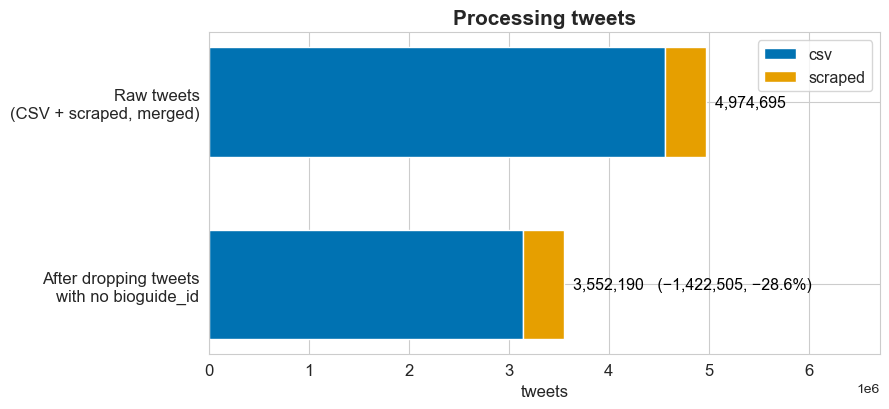

In [16]:
# data: tweet-processing funnel -> figures/data_funnel_tweets.png
# Same underlying data as data_analysis.ipynb section 8 (raw tweet corpus -> bioguide-mapped
# tweets, split by source), read from the cached aggregates rather than the 1.77 GB pickle.
# Restyled for the thesis: footnotesize-or-larger labels once the PNG is placed at ~textwidth,
# two-line y-axis labels, and a short title.
import json
T  = json.loads((ta.DERIVED_DIR / 'tweets_summary.json').read_text())
ST = json.loads((ta.DERIVED_DIR / 'tweet_source_totals.json').read_text())

tweet_funnel = pd.DataFrame([
    ('Raw tweets\n(CSV + scraped, merged)',        T['n_total'],         ST['csv_raw'],    ST['scraped_raw']),
    ('After dropping tweets\nwith no bioguide_id', T['n_with_bioguide'], ST['csv_mapped'], ST['scraped_mapped']),
], columns=['stage', 'total', 'csv', 'scraped'])
tweet_funnel['lost_from_prev']     = -tweet_funnel['total'].diff() + 0.0
tweet_funnel['pct_lost_from_prev'] = (tweet_funnel['lost_from_prev'] / tweet_funnel['total'].shift() * 100).round(1)

fig, ax = plt.subplots(figsize=(9, 4.2))
n = len(tweet_funnel)
y = np.arange(n)[::-1]

LABEL_FS, TICK_FS, ANNOT_FS, TITLE_FS = 12, 12, 11.5, 15

for i, (yy, row) in enumerate(zip(y, tweet_funnel.itertuples())):
    ax.barh(yy, row.csv, color=ta.PALETTE['Yea'], height=0.6,
            label='csv' if i == 0 else None)
    ax.barh(yy, row.scraped, left=row.csv, color=ta.PALETTE['accent'], height=0.6,
            label='scraped' if i == 0 else None)
    loss, pct = row.lost_from_prev, row.pct_lost_from_prev
    detail = '' if pd.isna(loss) else f'   (−{int(loss):,}, −{pct:.1f}%)'
    ax.text(row.total, yy, f'  {int(row.total):,}{detail}', va='center', fontsize=ANNOT_FS,
        color='black')

ax.set_yticks(y); ax.set_yticklabels(tweet_funnel['stage'], fontsize=TICK_FS)
ax.set_xlabel('tweets', fontsize=LABEL_FS)
ax.tick_params(axis='x', labelsize=TICK_FS)
ax.set_xlim(0, tweet_funnel['total'].max() * 1.35)
ax.set_title('Processing tweets', fontsize=TITLE_FS, fontweight='bold')
ax.legend(fontsize=ANNOT_FS)
plt.tight_layout(); ta.save_fig('data_funnel_tweets'); plt.show()

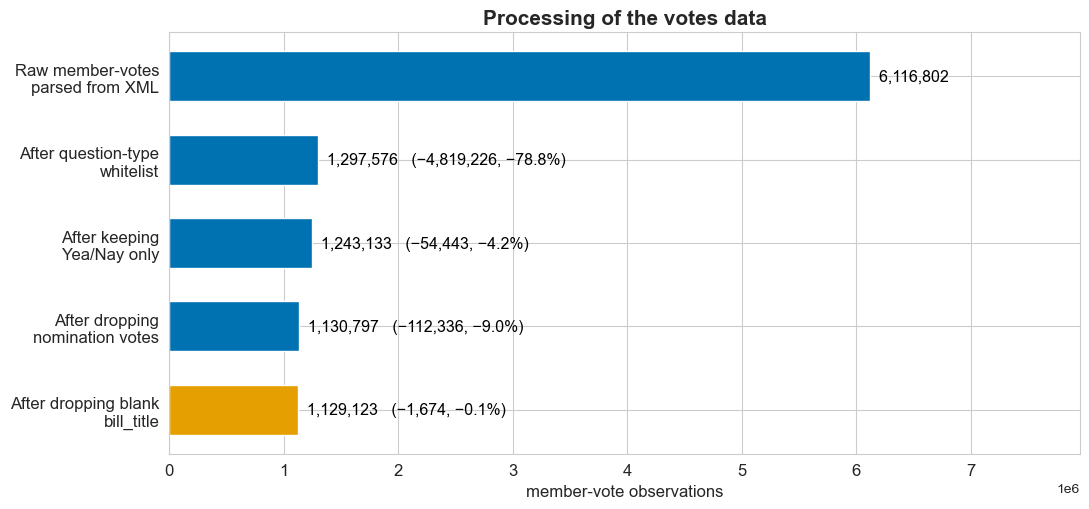

In [17]:
# data: votes-processing funnel -> figures/data_funnel_votes.png
# Same underlying data as data_analysis.ipynb section 6 (raw XML -> eligible-votes pool),
# read from the cached aggregates. Restyled to match the tweets funnel figure above:
# footnotesize-or-larger labels once placed at ~textwidth, two-line y-axis labels, black
# annotations throughout (no orange loss-text).
V = json.loads((ta.DERIVED_DIR / 'votes_summary.json').read_text())
F = json.loads((ta.DERIVED_DIR / 'funnel_stages.json').read_text())
comb = V['combined']
RAW_MEMBER_VOTES = 6_116_802   # recorded pre-whitelist total -- pre-whitelist CSVs no longer
                                # exist on disk, see data_analysis.ipynb §3/§6.

funnel = pd.DataFrame([
    ('Raw member-votes\nparsed from XML',   RAW_MEMBER_VOTES, np.nan, np.nan),
    ('After question-type\nwhitelist',      comb['rows'], comb['votes'], comb['members']),
    ('After keeping\nYea/Nay only',         *F['after_yea_nay']),
    ('After dropping\nnomination votes',    *F['after_nominations']),
    ('After dropping blank\nbill_title',    *F['after_bill_title']),
], columns=['stage', 'member_votes', 'unique_roll_calls', 'unique_members'])
funnel['lost_from_prev']     = -funnel['member_votes'].diff() + 0.0
funnel['pct_lost_from_prev'] = (funnel['lost_from_prev'] / funnel['member_votes'].shift() * 100).round(1)

fig, ax = plt.subplots(figsize=(11, 5.2))
n = len(funnel)
vals = funnel['member_votes'].to_numpy(dtype=float)
y = np.arange(n)[::-1]

TICK_FS, LABEL_FS, ANNOT_FS, TITLE_FS = 12, 12, 11.5, 15

colors = [ta.PALETTE['Yea']] * (n - 1) + [ta.PALETTE['accent']]
ax.barh(y, vals, color=colors, height=0.6)
ax.set_yticks(y); ax.set_yticklabels(funnel['stage'], fontsize=TICK_FS)
ax.set_xlabel('member-vote observations', fontsize=LABEL_FS)
ax.tick_params(axis='x', labelsize=TICK_FS)
ax.set_xlim(0, vals.max() * 1.30)

for i, (yy, v) in enumerate(zip(y, vals)):
    loss, pct = funnel['lost_from_prev'].iloc[i], funnel['pct_lost_from_prev'].iloc[i]
    count_txt = f'{int(v):,}'
    if pd.isna(loss):
        label = f'  {count_txt}'
    elif loss > 0:
        label = f'  {count_txt}   (−{int(loss):,}, −{pct:.1f}%)'
    else:
        label = f'  {count_txt}   (no rows lost)'
    ax.text(v, yy, label, va='center', fontsize=ANNOT_FS, color='black')

ax.set_title('Processing of the votes data', fontsize=TITLE_FS, fontweight='bold')
plt.tight_layout(); ta.save_fig('data_funnel_votes'); plt.show()

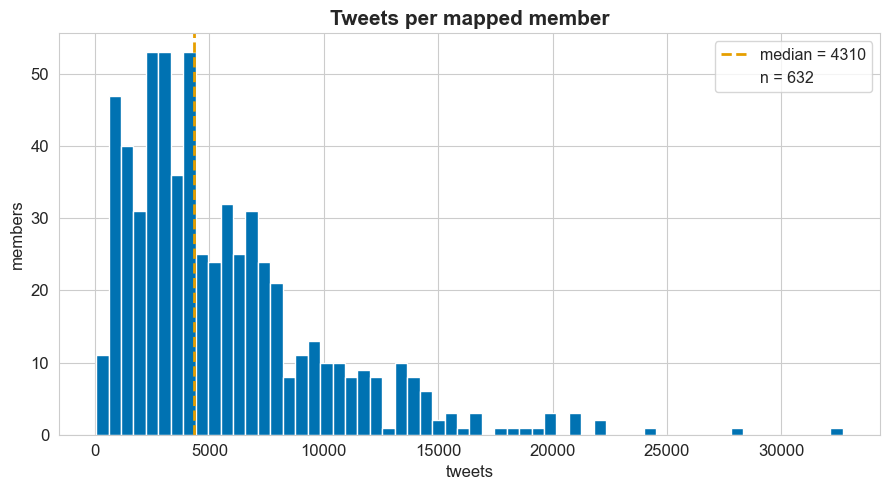

count      632.0
mean      5620.6
std       4439.2
min         47.0
25%       2552.0
50%       4309.5
75%       7253.0
max      32682.0
Name: n_tweets, dtype: float64

In [18]:
# data: tweets per mapped member -> figures/data_tweets_per_member.png
# Same underlying data as data_analysis.ipynb section 8/9. n moved from the title into the
# legend, and axis labels bumped to the same footnotesize-or-larger convention as the two
# funnel figures above.
tpm = pd.read_parquet(ta.DERIVED_DIR / 'tweets_per_member.parquet')

TICK_FS, LABEL_FS, ANNOT_FS, TITLE_FS = 12, 12, 11.5, 15

fig, ax = plt.subplots(figsize=(9, 5))
ax.hist(tpm['n_tweets'], bins=60, color=ta.PALETTE['Yea'], edgecolor='white')
median = tpm['n_tweets'].median()
median_line = ax.axvline(median, c=ta.PALETTE['accent'], ls='--', lw=2)

ax.set_title('Tweets per mapped member', fontsize=TITLE_FS, fontweight='bold')
ax.set_xlabel('tweets', fontsize=LABEL_FS)
ax.set_ylabel('members', fontsize=LABEL_FS)
ax.tick_params(axis='both', labelsize=TICK_FS)
# Two separate legend entries (not one two-line label) -- a multi-line label centers its
# single handle on the whole text block, which floats the dashed line between the two rows
# instead of next to "median". A second, invisible handle keeps "n" as its own row with no
# handle beside it.
n_handle = plt.Line2D([], [], color='none')
ax.legend([median_line, n_handle], [f'median = {median:.0f}', f'n = {len(tpm)}'],
          fontsize=ANNOT_FS, handlelength=1.6)
plt.tight_layout(); ta.save_fig('data_tweets_per_member'); plt.show()
tpm['n_tweets'].describe().round(1)

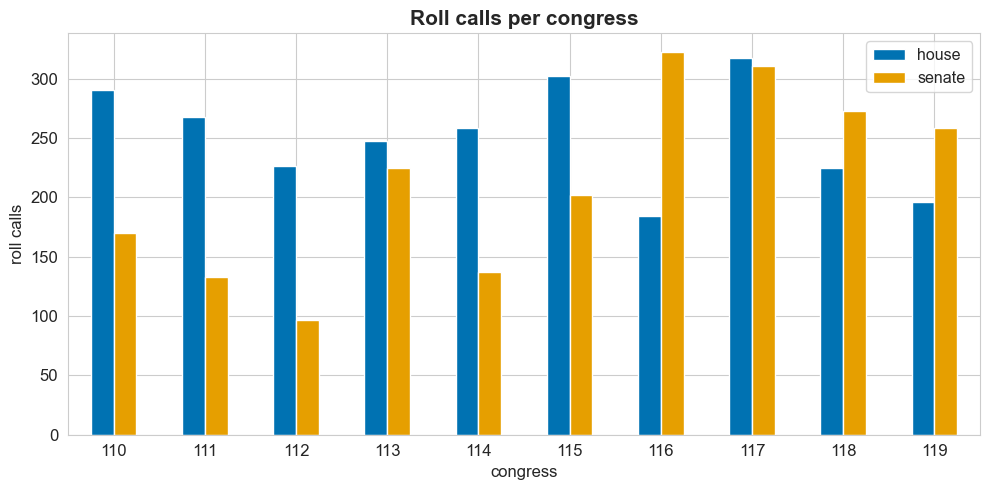

chamber,house,senate
congress,,
110,290,170
111,268,133
112,226,97
113,247,225
114,258,137
115,302,202
116,184,322
117,317,311
118,225,273


In [19]:
# data: roll calls per congress, by chamber -> figures/data_rollcalls_per_congress.png
# Restyled to match the other data-chapter figures: footnotesize-or-larger labels, short title.
vpc = pd.read_parquet(ta.DERIVED_DIR / 'votes_per_congress.parquet')
piv = vpc.pivot(index='congress', columns='chamber', values='n_votes').fillna(0)

TICK_FS, LABEL_FS, ANNOT_FS, TITLE_FS = 12, 12, 11.5, 15

fig, ax = plt.subplots(figsize=(10, 5))
piv.plot(kind='bar', ax=ax, color=[ta.PALETTE['house'], ta.PALETTE['senate']])
ax.set_title('Roll calls per congress', fontsize=TITLE_FS, fontweight='bold')
ax.set_ylabel('roll calls', fontsize=LABEL_FS)
ax.set_xlabel('congress', fontsize=LABEL_FS)
ax.set_xticklabels(ax.get_xticklabels(), rotation=0, fontsize=TICK_FS)
ax.tick_params(axis='y', labelsize=TICK_FS)
ax.legend(title='', fontsize=ANNOT_FS)
plt.tight_layout(); ta.save_fig('data_rollcalls_per_congress'); plt.show()
piv.astype(int)

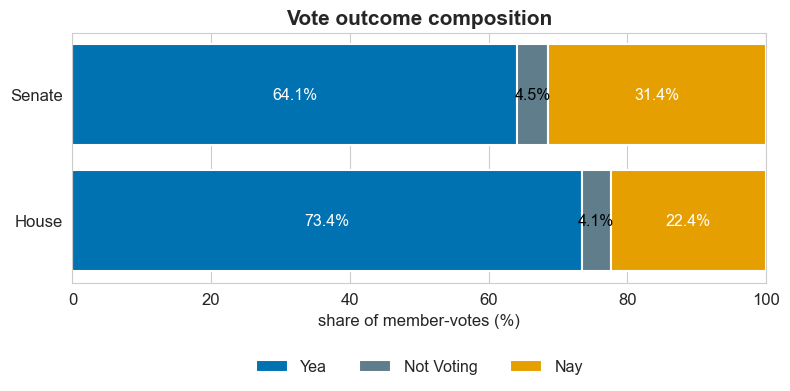

vote_cast,Yea,Not Voting,Nay
chamber,,,
house,73.44,4.14,22.42
senate,64.08,4.49,31.43


In [20]:
# data: vote outcome composition (class imbalance) -> figures/data_imbalance_vote_outcome.png
# Restyled to match the other data-chapter figures: footnotesize-or-larger labels, short title.
vc = pd.read_parquet(ta.DERIVED_DIR / 'votes_cast.parquet').pivot(index='chamber', columns='vote_cast', values='n')
vc = vc[['Yea', 'Not Voting', 'Nay']]  # fixed stack order, not alphabetical, so it reads Yea-first
vc_pct = vc.div(vc.sum(axis=1), axis=0) * 100

TICK_FS, LABEL_FS, ANNOT_FS, TITLE_FS = 12, 12, 11.5, 15

fig, ax = plt.subplots(figsize=(8, 4.2))
left = np.zeros(len(vc_pct))
colors = {'Yea': ta.PALETTE['Yea'], 'Not Voting': ta.PALETTE['neutral'], 'Nay': ta.PALETTE['Nay']}
for col in vc_pct.columns:
    ax.barh(vc_pct.index.str.title(), vc_pct[col], left=left, color=colors[col], label=col,
            edgecolor='white', linewidth=1.5)
    for i, (v, l) in enumerate(zip(vc_pct[col], left)):
        if v > 2:
            ax.text(l + v / 2, i, f'{v:.1f}%', ha='center', va='center', fontsize=ANNOT_FS,
                    color='white' if col != 'Not Voting' else 'black')
    left += vc_pct[col].values
ax.set_xlim(0, 100)
ax.set_xlabel('share of member-votes (%)', fontsize=LABEL_FS)
ax.tick_params(axis='both', labelsize=TICK_FS)
ax.set_title('Vote outcome composition', fontsize=TITLE_FS, fontweight='bold')
ax.legend(loc='upper center', bbox_to_anchor=(0.5, -0.25), ncol=3, frameon=False, fontsize=ANNOT_FS)
plt.tight_layout(); ta.save_fig('data_imbalance_vote_outcome'); plt.show()
vc_pct.round(2)

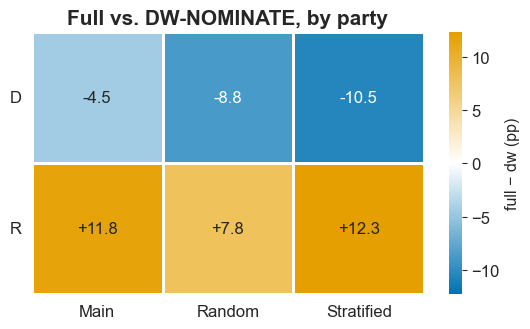

full - dw, percentage points (positive = LLM ahead, negative = dw ahead):


,Main,Random,Stratified
party,,,
D,-4.5,-8.8,-10.5
R,11.8,7.8,12.3


In [21]:
# comparison: full vs. DW-NOMINATE accuracy by party -> figures/comparison_party_dw.png
# Same computation as model_comparison.ipynb §5.1, rebuilt here from S (already loaded in
# setup) so this notebook is self-contained. Restyled: footnotesize-or-larger labels, short
# title, and a diverging colormap built from the SAME blue/orange pair used everywhere else
# in the thesis (RdBu_r silently introduced red, a third hue no other figure uses).
SAMPLE_SHORT = {'main': 'Main', 'random': 'Random', 'stratified': 'Stratified'}
order = ['D', 'R']
diff_rows = {}
for s in SAMPLES:
    e = S[s]
    if 'idx_dw' not in e:
        continue
    y2, preds2, meta2 = ta.aligned_matrix(e['core'] + ['dw'], e['idx_dw'], sample=s)
    corr2 = {k: (v == y2) for k, v in preds2.items()}
    frames = []
    for name in ['full', 'dw']:
        g = ta.groupby_acc_ci(corr2[name], meta2, 'party', B=2000, cluster=meta2['vote_id'].to_numpy())
        g['run'] = name
        frames.append(g.reset_index())
    t = pd.concat(frames, ignore_index=True).pivot(index='party', columns='run', values='accuracy')
    diff_rows[SAMPLE_SHORT.get(s, s)] = (t['full'] - t['dw']).reindex(order) * 100

diff_df = pd.DataFrame(diff_rows)

from matplotlib.colors import LinearSegmentedColormap
BLUE_ORANGE_DIVERGING = LinearSegmentedColormap.from_list(
    'blue_orange_diverging', [ta.PALETTE['Yea'], '#FFFFFF', ta.PALETTE['Nay']])

TICK_FS, ANNOT_FS, TITLE_FS, CBAR_FS = 12, 12, 15, 11.5

fig, ax = plt.subplots(figsize=(5.5, 3.4))
vmax = diff_df.abs().to_numpy().max()
hm = sns.heatmap(diff_df, annot=True, fmt='+.1f', annot_kws={'fontsize': ANNOT_FS},
                 cmap=BLUE_ORANGE_DIVERGING, center=0, vmin=-vmax, vmax=vmax,
                 cbar_kws={'label': 'full − dw (pp)'}, linewidths=1, linecolor='white', ax=ax)
ax.set_ylabel(''); ax.set_xlabel('')
ax.set_xticklabels(ax.get_xticklabels(), rotation=0, fontsize=TICK_FS)
ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=TICK_FS)
ax.set_title('Full vs. DW-NOMINATE, by party', fontsize=TITLE_FS, fontweight='bold')
cbar = hm.collections[0].colorbar
cbar.set_label('full − dw (pp)', fontsize=CBAR_FS)
cbar.ax.tick_params(labelsize=TICK_FS)
plt.tight_layout(); ta.save_fig('comparison_party_dw'); plt.show()

print('full - dw, percentage points (positive = LLM ahead, negative = dw ahead):')
diff_df.round(1)

In [22]:
# Table: party composition of member-vote pairs at the "after question-type whitelist"
# stage -> tab:member_votes
V = json.loads((ta.DERIVED_DIR / 'votes_summary.json').read_text())
party = {}
for ch in ('house', 'senate'):
    for k, v in V[ch]['party'].items():
        key = 'I' if k in ('I', 'ID') else k
        party[key] = party.get(key, 0) + v

MEMBER_VOTES = pd.DataFrame({'member_votes': party}).reindex(['D', 'R', 'I'])
MEMBER_VOTES['pct'] = (MEMBER_VOTES['member_votes'] / MEMBER_VOTES['member_votes'].sum() * 100).round(1)
MEMBER_VOTES

,member_votes,pct
D,639511,49.3
R,653350,50.4
I,4715,0.4


In [23]:
# Step 2: format MEMBER_VOTES (computed above, unmodified) as LaTeX.
lines = []
lines.append('\\begin{table}[htbp]')
lines.append('\\centering')
lines.append('\\begin{tabular}{lrr}')
lines.append('\\toprule')
lines.append(' & \\textbf{Member-vote pairs} & \\textbf{Percentage (\\%)} \\\\')
lines.append('\\midrule')
for party_key, r in MEMBER_VOTES.iterrows():
    n_str = f"{int(r['member_votes']):,}".replace(',', '{,}')
    lines.append(f"{party_key} & {n_str} & {r['pct']:.1f} \\\\")
lines.append('\\bottomrule')
lines.append('\\end{tabular}')
lines.append('\\caption{Party composition: distribution of member-vote pairs by party, at the '
             'post-whitelist stage (\\S3/\\S6).}')
lines.append('\\label{tab:member_votes}')
lines.append('\\end{table}')
print('\n'.join(lines))

\begin{table}[htbp]
\centering
\begin{tabular}{lrr}
\toprule
 & \textbf{Member-vote pairs} & \textbf{Percentage (\%)} \\
\midrule
D & 639{,}511 & 49.3 \\
R & 653{,}350 & 50.4 \\
I & 4{,}715 & 0.4 \\
\bottomrule
\end{tabular}
\caption{Party composition: distribution of member-vote pairs by party, at the post-whitelist stage (\S3/\S6).}
\label{tab:member_votes}
\end{table}


In [24]:
# Table: contested vs. unanimous roll calls by chamber, at the 0.80 competitiveness cut
# (config.COMPETITIVENESS_THRESHOLDS) -> tab:contested_unanimous
wf = pd.read_parquet(ta.DERIVED_DIR / 'vote_winner_frac.parquet')
thr = 0.80
wf['bucket'] = np.where(wf['winner_frac'] >= thr, 'unanimous', 'contested')
CONTESTED_UNANIMOUS = wf.groupby(['chamber', 'bucket']).size().unstack(fill_value=0)[['contested', 'unanimous']]
CONTESTED_UNANIMOUS['total'] = CONTESTED_UNANIMOUS.sum(axis=1)
CONTESTED_UNANIMOUS = CONTESTED_UNANIMOUS.reindex(['house', 'senate'])
CONTESTED_UNANIMOUS

bucket,contested,unanimous,total
chamber,,,
house,1308,1205,2513
senate,1583,545,2128


In [25]:
# Step 2: format CONTESTED_UNANIMOUS (computed above, unmodified) as LaTeX.
lines = []
lines.append('\\begin{table}[htbp]')
lines.append('\\centering')
lines.append('\\begin{tabular}{lrrr}')
lines.append('\\toprule')
lines.append('\\textbf{Chamber} & \\textbf{Total} & \\textbf{Contested} & \\textbf{Unanimous} \\\\')
lines.append('\\midrule')
for ch, r in CONTESTED_UNANIMOUS.iterrows():
    total = r['total']
    c_pct = r['contested'] / total * 100
    u_pct = r['unanimous'] / total * 100
    lines.append(f"{ch.title():<6} & {total} & {r['contested']} ({c_pct:.1f}\\%) & "
                 f"{r['unanimous']} ({u_pct:.1f}\\%) \\\\")
lines.append('\\bottomrule')
lines.append('\\end{tabular}')
lines.append('\\caption{Share of contested and unanimous roll calls by chamber, at the 0.80 '
             'winner-share cut.}')
lines.append('\\label{tab:contested_unanimous}')
lines.append('\\end{table}')
print('\n'.join(lines))

\begin{table}[htbp]
\centering
\begin{tabular}{lrrr}
\toprule
\textbf{Chamber} & \textbf{Total} & \textbf{Contested} & \textbf{Unanimous} \\
\midrule
House  & 2513 & 1308 (52.0\%) & 1205 (48.0\%) \\
Senate & 2128 & 1583 (74.4\%) & 545 (25.6\%) \\
\bottomrule
\end{tabular}
\caption{Share of contested and unanimous roll calls by chamber, at the 0.80 winner-share cut.}
\label{tab:contested_unanimous}
\end{table}


In [26]:
# Table: tweet-coverage filtering funnel -> tab:how_many_data
# Row 1 fixed from a stale figure (739,860): that number was computed on the wrong base --
# pipeline.py applies filter_to_covered() BEFORE the blank-bill_title filter, not after (see
# data_analysis.ipynb \S6/\S9). Recomputed live here on the correct post-nomination base
# (1,130,797 rows), confirmed against the pipeline's own live log output: 1,130,797 -> 740,891.
# Row 2 (563,364) is build_sample_cache.py's separate, later per-candidate 100-day-window
# check, already cross-verified earlier this session -- not recomputed here (would require
# joining every vote against per-member tweet dates).
import pickle
from pipeline import vote_filters

d = pd.concat([
    pd.read_csv(ta.DATA_DIR / f'{ch}_votes_members.csv',
               usecols=['vote_id', 'bioguide', 'vote_date', 'vote_cast', 'bill_title'],
               parse_dates=['vote_date'], low_memory=False).assign(chamber=ch)
    for ch in ('house', 'senate')
], ignore_index=True)
d = d.dropna(subset=['bioguide'])
d = d[d['vote_cast'].isin(['Yea', 'Nay'])]
nom = pd.Series([vote_filters.is_nomination(t, c) for t, c in zip(d['bill_title'], d['chamber'])], index=d.index)
d = d[~nom]

with open(ta.DATA_DIR / 'members_with_tweets.pkl', 'rb') as f:
    covered_bioguides = set(pickle.load(f)['bioguide'])
has_tweet = d[d['bioguide'].isin(covered_bioguides)]

HOW_MANY_DATA = pd.DataFrame([
    ('Member has ever tweeted', len(has_tweet)),
    ('...and has \u22651 tweet in the 100 days before the vote', 563_364),
], columns=['condition', 'rows'])
HOW_MANY_DATA

,condition,rows
0,Member has ever tweeted,740891
1,...and has ≥1 tweet in the 100 days before the...,563364


In [27]:
# Step 2: format HOW_MANY_DATA (computed above, unmodified) as LaTeX.
lines = []
lines.append('\\begin{table}[htbp]')
lines.append('\\centering')
lines.append('\\begin{tabular}{lr}')
lines.append('\\toprule')
lines.append('\\textbf{Condition} & \\textbf{Rows} \\\\')
lines.append('\\midrule')
for i, r in HOW_MANY_DATA.iterrows():
    n_str = f"{int(r['rows']):,}".replace(',', '{,}')
    bold = i == len(HOW_MANY_DATA) - 1
    n_str = f'\\textbf{{{n_str}}}' if bold else n_str
    lines.append(f"{r['condition']} & {n_str} \\\\")
lines.append('\\bottomrule')
lines.append('\\end{tabular}')
lines.append('\\caption{Sample size after successive tweet-coverage filtering steps. The two '
             'rows come from two different code paths (\\texttt{pipeline.py} vs.\\ '
             '\\texttt{build\\_sample\\_cache.py}) on two different base pools, not one '
             'single chained funnel -- see \\S6/\\S9/\\S11.}')
lines.append('\\label{tab:how_many_data}')
lines.append('\\end{table}')
print('\n'.join(lines))

\begin{table}[htbp]
\centering
\begin{tabular}{lr}
\toprule
\textbf{Condition} & \textbf{Rows} \\
\midrule
Member has ever tweeted & 740{,}891 \\
...and has ≥1 tweet in the 100 days before the vote & \textbf{563{,}364} \\
\bottomrule
\end{tabular}
\caption{Sample size after successive tweet-coverage filtering steps. The two rows come from two different code paths (\texttt{pipeline.py} vs.\ \texttt{build\_sample\_cache.py}) on two different base pools, not one single chained funnel -- see \S6/\S9/\S11.}
\label{tab:how_many_data}
\end{table}


In [28]:
# Table: distribution of bill-summary length in words, across roll calls that HAVE a
# summary (has_summary == True; 3,440 of 4,641 -- the other 1,201 have zero words and would
# distort every statistic below if included) -> tab:summary_stats
cov = pd.read_parquet(ta.DERIVED_DIR / 'bill_summary_coverage.parquet')
words = cov[cov['has_summary']]['n_words']
SUMMARY_STATS = pd.DataFrame([
    ('Count', int(words.count())), ('Mean', round(words.mean())), ('Min', int(words.min())),
    ('25th percentile', int(words.quantile(.25))), ('Median', int(words.median())),
    ('75th percentile', int(words.quantile(.75))), ('Max', int(words.max())),
], columns=['statistic', 'value'])
SUMMARY_STATS

,statistic,value
0,Count,3440
1,Mean,2660
2,Min,10
3,25th percentile,91
4,Median,227
5,75th percentile,1282
6,Max,62779


In [29]:
# Step 2: format SUMMARY_STATS (computed above, unmodified) as LaTeX.
lines = []
lines.append('\\begin{table}[htbp]')
lines.append('\\centering')
lines.append('\\begin{tabular}{lr}')
lines.append('\\toprule')
lines.append('\\textbf{Statistic} & \\textbf{Value} \\\\')
lines.append('\\midrule')
for _, r in SUMMARY_STATS.iterrows():
    v_str = f"{int(r['value']):,}".replace(',', '{,}')
    lines.append(f"{r['statistic']:<16} & {v_str} \\\\")
lines.append('\\bottomrule')
lines.append('\\end{tabular}')
lines.append('\\caption{Distribution of summary length in words, across the 3,440 roll calls '
             'that have a bill summary (\\S5).}')
lines.append('\\label{tab:summary_stats}')
lines.append('\\end{table}')
print('\n'.join(lines))

\begin{table}[htbp]
\centering
\begin{tabular}{lr}
\toprule
\textbf{Statistic} & \textbf{Value} \\
\midrule
Count            & 3{,}440 \\
Mean             & 2{,}660 \\
Min              & 10 \\
25th percentile  & 91 \\
Median           & 227 \\
75th percentile  & 1{,}282 \\
Max              & 62{,}779 \\
\bottomrule
\end{tabular}
\caption{Distribution of summary length in words, across the 3,440 roll calls that have a bill summary (\S5).}
\label{tab:summary_stats}
\end{table}


In [30]:
# Table: sample size, common evaluable set, and DW-scorable subset, across samples
# -> tab:desc_common_evaluable_set
RAW_SAMPLE_SIZE = {'main': 10_000, 'random': 10_000, 'stratified': 9_272}
SAMPLE_DISPLAY_ = {'main': 'Main sample', 'random': 'Random sample', 'stratified': 'Stratified sample'}

DESC_CES = pd.DataFrame([
    {'sample': SAMPLE_DISPLAY_.get(s, s), 'sample_size': RAW_SAMPLE_SIZE[s],
     'predictions': len(S[s]['idx']), 'dw_scorable_set': len(S[s]['idx_dw'])}
    for s in SAMPLES if s in RAW_SAMPLE_SIZE
])
DESC_CES

,sample,sample_size,predictions,dw_scorable_set
0,Main sample,10000,9961,8774
1,Random sample,10000,9967,7426
2,Stratified sample,9272,9241,7132


In [31]:
# Step 2: format DESC_CES (computed above, unmodified) as LaTeX.
lines = []
lines.append('\\begin{table}[htbp]')
lines.append('\\centering')
lines.append('\\begin{tabular}{lrrr}')
lines.append('\\toprule')
lines.append('\\textbf{Sample} & \\textbf{Sample size} & \\textbf{Predictions} & '
             '\\textbf{DW-NOMINATE set} \\\\')
lines.append('\\midrule')
for _, r in DESC_CES.iterrows():
    fmt = lambda x: f'{int(x):,}'.replace(',', '{,}')
    lines.append(f"{r['sample']:<18} & {fmt(r['sample_size'])} & {fmt(r['predictions'])} & "
                 f"{fmt(r['dw_scorable_set'])} \\\\")
lines.append('\\bottomrule')
lines.append('\\end{tabular}')
lines.append('\\caption{Sample size, successful LLM predictions (common evaluable set), and '
             'the further-restricted DW-NOMINATE-scorable subset, across sampling strategies.}')
lines.append('\\label{tab:desc_common_evaluable_set}')
lines.append('\\end{table}')
print('\n'.join(lines))

\begin{table}[htbp]
\centering
\begin{tabular}{lrrr}
\toprule
\textbf{Sample} & \textbf{Sample size} & \textbf{Predictions} & \textbf{DW-NOMINATE set} \\
\midrule
Main sample        & 10{,}000 & 9{,}961 & 8{,}774 \\
Random sample      & 10{,}000 & 9{,}967 & 7{,}426 \\
Stratified sample  & 9{,}272 & 9{,}241 & 7{,}132 \\
\bottomrule
\end{tabular}
\caption{Sample size, successful LLM predictions (common evaluable set), and the further-restricted DW-NOMINATE-scorable subset, across sampling strategies.}
\label{tab:desc_common_evaluable_set}
\end{table}


In [32]:
# Table: bill-summary coverage by chamber, with the nomination-vote breakdown
# -> tab:coverage
cov = pd.read_parquet(ta.DERIVED_DIR / 'bill_summary_coverage.parquet')
rows = []
for ch in ['house', 'senate']:
    d = cov[cov['chamber'] == ch]
    total = len(d)
    with_summary = int(d['has_summary'].sum())
    missing = total - with_summary
    missing_nom = int((~d['has_summary'] & d['is_nomination']).sum())
    excl_nom_total = total - int(d['is_nomination'].sum())
    rows.append({
        'chamber': ch, 'roll_calls': total, 'with_summary': with_summary,
        'coverage_pct': round(with_summary / total * 100, 1), 'missing': missing,
        'missing_nomination': missing_nom,
        'coverage_excl_nom_pct': round(with_summary / excl_nom_total * 100, 1),
    })
COVERAGE = pd.DataFrame(rows).set_index('chamber')
COVERAGE

,roll_calls,with_summary,coverage_pct,missing,missing_nomination,coverage_excl_nom_pct
chamber,,,,,,
house,2513,2508,99.8,5,0,99.8
senate,2128,932,43.8,1196,1183,98.7


In [33]:
# Step 2: format COVERAGE (computed above, unmodified) as LaTeX.
def fmt_n(x):
    return f'{int(x):,}'.replace(',', '{,}')

lines = []
lines.append('\\begin{table}[htbp]')
lines.append('\\centering')
lines.append('\\begin{tabular}{lrr}')
lines.append('\\toprule')
lines.append(' & \\textbf{House} & \\textbf{Senate} \\\\')
lines.append('\\midrule')
h, s = COVERAGE.loc['house'], COVERAGE.loc['senate']
lines.append(f"Roll calls & {fmt_n(h['roll_calls'])} & {fmt_n(s['roll_calls'])} \\\\")
lines.append(f"With bill summary & {fmt_n(h['with_summary'])} & {fmt_n(s['with_summary'])} \\\\")
lines.append(f"Coverage (\\%) & {h['coverage_pct']:.1f} & {s['coverage_pct']:.1f} \\\\")
lines.append('\\addlinespace')
lines.append(f"Missing bill summary & {fmt_n(h['missing'])} & {fmt_n(s['missing'])} \\\\")
lines.append(f"\\quad of which are nomination votes & {fmt_n(h['missing_nomination'])} & "
             f"{fmt_n(s['missing_nomination'])} \\\\")
lines.append('\\addlinespace')
lines.append(f"Coverage without nominations (\\%) & {h['coverage_excl_nom_pct']:.1f} & "
             f"{s['coverage_excl_nom_pct']:.1f} \\\\")
lines.append('\\bottomrule')
lines.append('\\end{tabular}')
lines.append('\\caption{Bill-summary coverage for roll calls by chamber.}')
lines.append('\\label{tab:coverage}')
lines.append('\\end{table}')
print('\n'.join(lines))

\begin{table}[htbp]
\centering
\begin{tabular}{lrr}
\toprule
 & \textbf{House} & \textbf{Senate} \\
\midrule
Roll calls & 2{,}513 & 2{,}128 \\
With bill summary & 2{,}508 & 932 \\
Coverage (\%) & 99.8 & 43.8 \\
\addlinespace
Missing bill summary & 5 & 1{,}196 \\
\quad of which are nomination votes & 0 & 1{,}183 \\
\addlinespace
Coverage without nominations (\%) & 99.8 & 98.7 \\
\bottomrule
\end{tabular}
\caption{Bill-summary coverage for roll calls by chamber.}
\label{tab:coverage}
\end{table}


In [34]:
# Table: sample composition (contested/house/democrat/freshman shares) on each sample's
# common evaluable set -> tab:sample_composition_summary
SAMPLE_DISPLAY_ = {'main': 'Main', 'random': 'Random', 'stratified': 'Stratified'}
rows = []
for s in SAMPLES:
    meta = S[s]['meta']
    rows.append({
        'sample': SAMPLE_DISPLAY_.get(s, s), 'n': len(S[s]['idx']),
        'contested_pct': round((meta['competitiveness'] == 'contested').mean() * 100, 1),
        'house_pct': round((meta['chamber'] == 'house').mean() * 100, 1),
        'democrat_pct': round((meta['party'] == 'D').mean() * 100, 1),
        'freshman_pct': round((meta['freshman'] == 'freshman').mean() * 100, 1),
    })
SAMPLE_COMP = pd.DataFrame(rows)
SAMPLE_COMP

,sample,n,contested_pct,house_pct,democrat_pct,freshman_pct
0,Main,9961,73.8,75.7,51.3,13.0
1,Random,9967,52.5,86.2,52.0,12.7
2,Stratified,9241,55.1,88.4,50.8,13.8


In [35]:
# Step 2: format SAMPLE_COMP (computed above, unmodified) as LaTeX.
lines = []
lines.append('\\begin{table}[htbp]')
lines.append('\\centering')
lines.append('\\begin{tabular}{lrrrrr}')
lines.append('\\toprule')
lines.append('Sample & $n$ & Contested (\\%) & House (\\%) & Democrat (\\%) & Freshman (\\%) \\\\')
lines.append('\\midrule')
for _, r in SAMPLE_COMP.iterrows():
    n_str = f"{int(r['n']):,}".replace(',', '{,}')
    lines.append(f"{r['sample']:<10} & {n_str} & {r['contested_pct']:.1f} & {r['house_pct']:.1f} & "
                 f"{r['democrat_pct']:.1f} & {r['freshman_pct']:.1f} \\\\")
lines.append('\\bottomrule')
lines.append('\\end{tabular}')
lines.append("\\caption{Sample composition summary (\\%) on each sample's common evaluable set.}")
lines.append('\\label{tab:sample_composition_summary}')
lines.append('\\end{table}')
print('\n'.join(lines))

\begin{table}[htbp]
\centering
\begin{tabular}{lrrrrr}
\toprule
Sample & $n$ & Contested (\%) & House (\%) & Democrat (\%) & Freshman (\%) \\
\midrule
Main       & 9{,}961 & 73.8 & 75.7 & 51.3 & 13.0 \\
Random     & 9{,}967 & 52.5 & 86.2 & 52.0 & 12.7 \\
Stratified & 9{,}241 & 55.1 & 88.4 & 50.8 & 13.8 \\
\bottomrule
\end{tabular}
\caption{Sample composition summary (\%) on each sample's common evaluable set.}
\label{tab:sample_composition_summary}
\end{table}


In [36]:
# Table: contested-only pre/post training-cutoff comparison (full pipeline only) --
# standalone version of the contested-only half of MEMORIZATION_CHECK above, in the exact
# format finalized for the discussion chapter (merged 95% CI column, no delta column).
# Reuses PRIMARY_CUTOFF and two_sample_boot_diff, already defined above. -> tab:temporal_cutoff
def sig_stars_tc(p):
    return '***' if p < 0.001 else '**' if p < 0.01 else '*' if p < 0.05 else 'n.s.'

TEMPORAL_ROWS = []
for s in SAMPLES:
    e = S[s]
    if 'full' not in e['correct']:
        continue
    vd = pd.to_datetime(e['meta']['vote_date'])
    post = (vd > PRIMARY_CUTOFF).to_numpy()
    contested = (e['meta']['competitiveness'] == 'contested').to_numpy()
    res = two_sample_boot_diff(e['correct']['full'][contested & ~post], e['cluster'][contested & ~post],
                               e['correct']['full'][contested & post], e['cluster'][contested & post])
    TEMPORAL_ROWS.append({
        'sample': s, 'n_pre': res['n_pre'], 'n_post': res['n_post'],
        'acc_pre': res['acc_pre'], 'acc_post': res['acc_post'],
        'ci_low_pp': res['ci_low'] * 100, 'ci_high_pp': res['ci_high'] * 100,
        'p_boot': res['p_boot'], 'sig': sig_stars_tc(res['p_boot']),
    })
TEMPORAL_CUTOFF = pd.DataFrame(TEMPORAL_ROWS)
TEMPORAL_CUTOFF

,sample,n_pre,n_post,acc_pre,acc_post,ci_low_pp,ci_high_pp,p_boot,sig
0,main,6615,738,0.849887,0.746612,1.819332,19.414425,0.0180,*
1,random,4385,845,0.788597,0.760947,-2.032393,7.573385,0.2612,n.s.
2,stratified,4338,753,0.823882,0.706507,2.441690,21.686844,0.0110,*


In [37]:
# Step 2: format TEMPORAL_CUTOFF (computed above, unmodified) as LaTeX.
SAMPLE_DISPLAY_ = {'main': 'Main', 'random': 'Random', 'stratified': 'Stratified'}
lines = []
lines.append('\\begin{table}[htbp]')
lines.append('\\centering')
lines.append('\\begin{tabular}{lrrrrrr}')
lines.append('\\toprule')
lines.append('\\textbf{Sample} & \\textbf{$n_{\\text{pre}}$} & \\textbf{$n_{\\text{post}}$} & '
             '\\textbf{Acc.\\ pre} & \\textbf{Acc.\\ post} & \\textbf{95\\% CI (pp)} & '
             '\\textbf{$p$} \\\\')
lines.append('\\midrule')
for _, r in TEMPORAL_CUTOFF.iterrows():
    stars = {'***': ' ($^{***}$)', '**': ' ($^{**}$)', '*': ' ($^{*}$)', 'n.s.': ' (n.s.)'}[r['sig']]
    p_str = '$<0.001$' if r['p_boot'] < 0.001 else f"${r['p_boot']:.3f}$"
    ci = f"[${r['ci_low_pp']:+.2f}$, ${r['ci_high_pp']:+.2f}$]"
    lines.append(f"{SAMPLE_DISPLAY_.get(r['sample'], r['sample']):<10} & {int(r['n_pre'])} & "
                 f"{int(r['n_post'])} & {r['acc_pre']:.4f} & {r['acc_post']:.4f} & {ci:<22} & "
                 f"{p_str}{stars} \\\\")
lines.append('\\bottomrule')
lines.append('\\end{tabular}')
lines.append('\\caption{Accuracy before and after the training-data cutoff (2024-06-01), '
             'contested votes only, full pipeline. The 95\\% CI and $p$ are for the accuracy '
             'difference (pre-cutoff minus post-cutoff), from a two-sample cluster bootstrap '
             '(clustered on roll call, $B=10{,}000$), uncorrected. $^{*}p<0.05$, $^{**}p<0.01$, '
             '$^{***}p<0.001$, n.s.\\ = not significant.}')
lines.append('\\label{tab:temporal_cutoff}')
lines.append('\\end{table}')
print('\n'.join(lines))

\begin{table}[htbp]
\centering
\begin{tabular}{lrrrrrr}
\toprule
\textbf{Sample} & \textbf{$n_{\text{pre}}$} & \textbf{$n_{\text{post}}$} & \textbf{Acc.\ pre} & \textbf{Acc.\ post} & \textbf{95\% CI (pp)} & \textbf{$p$} \\
\midrule
Main       & 6615 & 738 & 0.8499 & 0.7466 & [$+1.82$, $+19.41$]    & $0.018$ ($^{*}$) \\
Random     & 4385 & 845 & 0.7886 & 0.7609 & [$-2.03$, $+7.57$]     & $0.261$ (n.s.) \\
Stratified & 4338 & 753 & 0.8239 & 0.7065 & [$+2.44$, $+21.69$]    & $0.011$ ($^{*}$) \\
\bottomrule
\end{tabular}
\caption{Accuracy before and after the training-data cutoff (2024-06-01), contested votes only, full pipeline. The 95\% CI and $p$ are for the accuracy difference (pre-cutoff minus post-cutoff), from a two-sample cluster bootstrap (clustered on roll call, $B=10{,}000$), uncorrected. $^{*}p<0.05$, $^{**}p<0.01$, $^{***}p<0.001$, n.s.\ = not significant.}
\label{tab:temporal_cutoff}
\end{table}


In [38]:
# Table: percentage of votes DW-NOMINATE can score, by competitiveness/chamber and
# sample -> tab:dw_coverage_skew
SAMPLE_DISPLAY_ = {'main': 'Main', 'random': 'Random', 'stratified': 'Stratified'}
rows = {}
for s in SAMPLES:
    e = S[s]
    if 'idx_dw' not in e:
        continue
    meta = e['meta']
    scorable = meta.index.isin(e['idx_dw'])
    col = {}
    for val in ['contested', 'unanimous']:
        mask = (meta['competitiveness'] == val).to_numpy()
        col[val.capitalize()] = round(scorable[mask].mean() * 100, 1)
    for val in ['house', 'senate']:
        mask = (meta['chamber'] == val).to_numpy()
        col[val.capitalize()] = round(scorable[mask].mean() * 100, 1)
    rows[SAMPLE_DISPLAY_.get(s, s)] = col

DW_COVERAGE_SKEW = pd.DataFrame(rows).reindex(['Contested', 'Unanimous', 'House', 'Senate'])
DW_COVERAGE_SKEW

,Main,Random,Stratified
Contested,100.0,100.0,100.0
Unanimous,54.5,46.4,49.2
House,87.5,71.7,75.3
Senate,89.9,92.0,91.6


In [39]:
# Step 2: format DW_COVERAGE_SKEW (computed above, unmodified) as LaTeX.
lines = []
lines.append('\\begin{table}[htbp]')
lines.append('\\centering')
lines.append('\\begin{tabular}{lccc}')
lines.append('\\toprule')
cols = list(DW_COVERAGE_SKEW.columns)
lines.append(' & ' + ' & '.join(cols) + ' \\\\')
lines.append('\\midrule')
lines.append('Contested & ' + ' & '.join(f"{DW_COVERAGE_SKEW.loc['Contested', c]:.1f}" for c in cols) + ' \\\\')
lines.append('Unanimous & ' + ' & '.join(f"{DW_COVERAGE_SKEW.loc['Unanimous', c]:.1f}" for c in cols) + ' \\\\')
lines.append('\\midrule')
lines.append('House      & ' + ' & '.join(f"{DW_COVERAGE_SKEW.loc['House', c]:.1f}" for c in cols) + ' \\\\')
lines.append('Senate     & ' + ' & '.join(f"{DW_COVERAGE_SKEW.loc['Senate', c]:.1f}" for c in cols) + ' \\\\')
lines.append('\\bottomrule')
lines.append('\\end{tabular}')
lines.append('\\caption{Percentage of votes DW-NOMINATE can score, by category and sample.}')
lines.append('\\label{tab:dw_coverage_skew}')
lines.append('\\end{table}')
print('\n'.join(lines))

\begin{table}[htbp]
\centering
\begin{tabular}{lccc}
\toprule
 & Main & Random & Stratified \\
\midrule
Contested & 100.0 & 100.0 & 100.0 \\
Unanimous & 54.5 & 46.4 & 49.2 \\
\midrule
House      & 87.5 & 71.7 & 75.3 \\
Senate     & 89.9 & 92.0 & 91.6 \\
\bottomrule
\end{tabular}
\caption{Percentage of votes DW-NOMINATE can score, by category and sample.}
\label{tab:dw_coverage_skew}
\end{table}


In [40]:
# Appendix table: roll-call question types dropped by the question-type whitelist
# (data_cleaning.ipynb cell 4). The pre-whitelist member-level CSVs were overwritten in place
# and no longer exist on disk, so this uses the separate, roll-call-level house_votes.csv /
# senate_votes.csv files, which still carry the full pre-whitelist question field (missing
# congress 119, unlike the member-level files, so counts are a lower bound, not exact matches
# to the funnel's 6,116,802 figure). -> tab:dropped_questions
KEEP_QUESTIONS = [
    'On Passage of the Bill', 'On Passage', 'On Overriding the Veto',
    'On the Cloture Motion', 'On Agreeing to the Conference Report',
    'On the Conference Report', 'On Motion to Suspend the Rules and Pass',
    'On the Joint Resolution', 'On Consideration of the Joint Resolution',
]

h = pd.read_csv(ta.DATA_DIR / 'house_votes.csv', low_memory=False)
s = pd.read_csv(ta.DATA_DIR / 'senate_votes.csv', low_memory=False)
h_dropped = h['vote_question'].value_counts().pipe(lambda c: c[~c.index.isin(KEEP_QUESTIONS)])
s_dropped = s['question'].value_counts().pipe(lambda c: c[~c.index.isin(KEEP_QUESTIONS)])

THRESHOLD = 15  # House only -- Senate's dropped list is short enough to show in full
h_shown = h_dropped[h_dropped >= THRESHOLD]
h_tail = h_dropped[h_dropped < THRESHOLD]

DROPPED_QUESTIONS = pd.concat([
    pd.DataFrame({'chamber': 'House', 'question': h_shown.index, 'roll_calls': h_shown.values}),
    pd.DataFrame({'chamber': 'House', 'question': [f'({len(h_tail)} further types, <{THRESHOLD} each)'],
                 'roll_calls': [int(h_tail.sum())]}),
    pd.DataFrame({'chamber': 'Senate', 'question': s_dropped.index, 'roll_calls': s_dropped.values}),
], ignore_index=True)
DROPPED_QUESTIONS

,chamber,question,roll_calls
0,House,On Agreeing to the Amendment,4012
1,House,On Agreeing to the Resolution,1117
2,House,"On Motion to Suspend the Rules and Pass, as Am...",1088
3,House,On Ordering the Previous Question,832
4,House,On Motion to Recommit with Instructions,636
5,House,On Motion to Suspend the Rules and Agree,476
6,House,"On Motion to Suspend the Rules and Agree, as A...",242
7,House,On Approving the Journal,183
8,House,On Motion to Adjourn,142
9,House,On Motion to Recommit,139


In [41]:
# Step 2: format DROPPED_QUESTIONS (computed above, unmodified) as LaTeX.
lines = []
lines.append('\\begin{table}[htbp]')
lines.append('\\centering')
lines.append('\\small')
lines.append('\\begin{tabular}{llr}')
lines.append('\\toprule')
lines.append('\\textbf{Chamber} & \\textbf{Question type} & \\textbf{Roll calls} \\\\')
lines.append('\\midrule')
for chamber, sub in DROPPED_QUESTIONS.groupby('chamber', sort=False):
    lines.append(f'\\multirow{{{len(sub)}}}{{*}}{{{chamber}}}')
    for _, r in sub.iterrows():
        q = r['question'].replace('&', '\\&')
        n_str = f"{int(r['roll_calls']):,}".replace(',', '{,}')
        lines.append(f"  & {q} & {n_str} \\\\")
    lines.append('\\addlinespace')
lines.append('\\bottomrule')
lines.append('\\end{tabular}')
lines.append('\\caption{Roll-call question types excluded by the question-type whitelist '
             '(\\S3), by chamber, with roll-call counts. House types with fewer than 15 '
             'occurrences are summarised in one row rather than listed individually; the '
             'Senate list is short enough to show in full. Counts are from '
             '\\texttt{house\\_votes.csv}/\\texttt{senate\\_votes.csv} (congresses '
             '110--118 only -- the pre-whitelist member-level data no longer exists on disk, '
             'see \\S3/\\S6), so these are a lower bound, not an exact match to the '
             'funnel\'s raw total.}')
lines.append('\\label{tab:dropped_questions}')
lines.append('\\end{table}')
print('\n'.join(lines))

\begin{table}[htbp]
\centering
\small
\begin{tabular}{llr}
\toprule
\textbf{Chamber} & \textbf{Question type} & \textbf{Roll calls} \\
\midrule
\multirow{25}{*}{House}
  & On Agreeing to the Amendment & 4{,}012 \\
  & On Agreeing to the Resolution & 1{,}117 \\
  & On Motion to Suspend the Rules and Pass, as Amended & 1{,}088 \\
  & On Ordering the Previous Question & 832 \\
  & On Motion to Recommit with Instructions & 636 \\
  & On Motion to Suspend the Rules and Agree & 476 \\
  & On Motion to Suspend the Rules and Agree, as Amended & 242 \\
  & On Approving the Journal & 183 \\
  & On Motion to Adjourn & 142 \\
  & On Motion to Recommit & 139 \\
  & Table Appeal of the Ruling of the Chair & 64 \\
  & On Motion to Instruct Conferees & 61 \\
  & On Motion to Table & 51 \\
  & On Motion to Suspend the Rules and Concur in the Senate Amendment & 46 \\
  & Table Motion to Reconsider & 41 \\
  & Call of the House & 29 \\
  & Election of the Speaker & 28 \\
  & On Motion to Concur in the Se

In [42]:
# Appendix table: roll-call question types KEPT by the question-type whitelist
# (data_cleaning.ipynb cell 4), with roll-call counts on the current, post-whitelist data --
# shorter and easier to read than the dropped-questions table above. -> tab:kept_questions
h = pd.read_csv(ta.DATA_DIR / 'house_votes_members.csv', usecols=['vote_id', 'question'],
               low_memory=False).drop_duplicates('vote_id')
s = pd.read_csv(ta.DATA_DIR / 'senate_votes_members.csv', usecols=['vote_id', 'question'],
               low_memory=False).drop_duplicates('vote_id')

KEPT_QUESTIONS = pd.concat([
    h['question'].value_counts().rename('roll_calls').rename_axis('question').reset_index().assign(chamber='House'),
    s['question'].value_counts().rename('roll_calls').rename_axis('question').reset_index().assign(chamber='Senate'),
], ignore_index=True)[['chamber', 'question', 'roll_calls']]
KEPT_QUESTIONS

,chamber,question,roll_calls
0,House,On Passage,1367
1,House,On Motion to Suspend the Rules and Pass,1093
2,House,On Agreeing to the Conference Report,52
3,House,On Consideration of the Joint Resolution,1
4,Senate,On the Cloture Motion,1652
5,Senate,On Passage of the Bill,282
6,Senate,On the Joint Resolution,126
7,Senate,On the Conference Report,50
8,Senate,On Overriding the Veto,18


In [43]:
# Step 2: format KEPT_QUESTIONS (computed above, unmodified) as LaTeX.
lines = []
lines.append('\\begin{table}[htbp]')
lines.append('\\centering')
lines.append('\\begin{tabular}{llr}')
lines.append('\\toprule')
lines.append('\\textbf{Chamber} & \\textbf{Question type} & \\textbf{Roll calls} \\\\')
lines.append('\\midrule')
for chamber, sub in KEPT_QUESTIONS.groupby('chamber', sort=False):
    lines.append(f'\\multirow{{{len(sub)}}}{{*}}{{{chamber}}}')
    for _, r in sub.sort_values('roll_calls', ascending=False).iterrows():
        n_str = f"{int(r['roll_calls']):,}".replace(',', '{,}')
        lines.append(f"  & {r['question']} & {n_str} \\\\")
    lines.append('\\addlinespace')
lines.append('\\bottomrule')
lines.append('\\end{tabular}')
lines.append('\\caption{Roll-call question types kept by the question-type whitelist '
             '(\\S3), by chamber, with roll-call counts on the current, post-whitelist '
             'data.}')
lines.append('\\label{tab:kept_questions}')
lines.append('\\end{table}')
print('\n'.join(lines))

\begin{table}[htbp]
\centering
\begin{tabular}{llr}
\toprule
\textbf{Chamber} & \textbf{Question type} & \textbf{Roll calls} \\
\midrule
\multirow{4}{*}{House}
  & On Passage & 1{,}367 \\
  & On Motion to Suspend the Rules and Pass & 1{,}093 \\
  & On Agreeing to the Conference Report & 52 \\
  & On Consideration of the Joint Resolution & 1 \\
\addlinespace
\multirow{5}{*}{Senate}
  & On the Cloture Motion & 1{,}652 \\
  & On Passage of the Bill & 282 \\
  & On the Joint Resolution & 126 \\
  & On the Conference Report & 50 \\
  & On Overriding the Veto & 18 \\
\addlinespace
\bottomrule
\end{tabular}
\caption{Roll-call question types kept by the question-type whitelist (\S3), by chamber, with roll-call counts on the current, post-whitelist data.}
\label{tab:kept_questions}
\end{table}


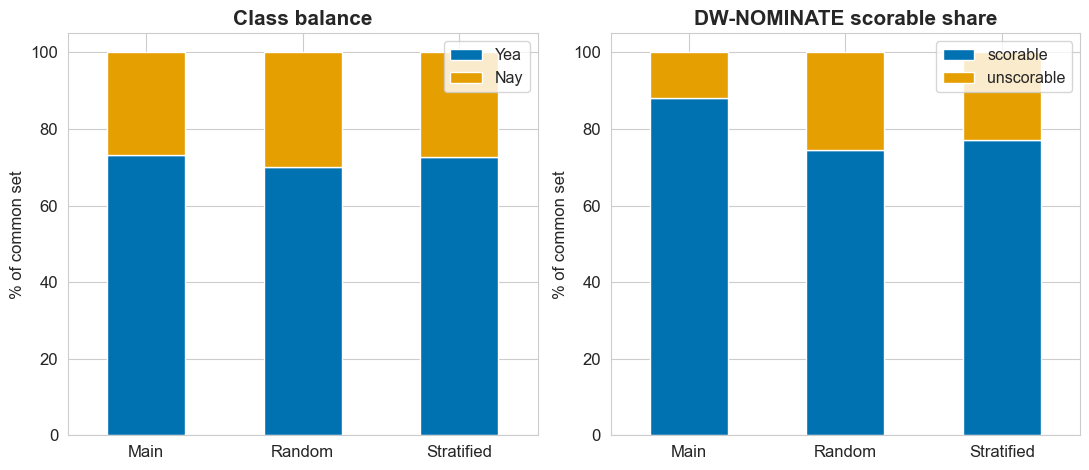

In [44]:
# data/comparison: sample overview -- class balance and DW-NOMINATE scorable share
# -> figures/desc_sample_overview.png
# Same computation as model_comparison.ipynb's descriptive section -- everything here already
# comes from S (setup, above). Uses "Main" rather than ta.sample_label()'s "Tweet-available
# sample", matching the Main/Random/Stratified naming used consistently everywhere else in
# this notebook.
SAMPLE_DISPLAY_ = {'main': 'Main', 'random': 'Random', 'stratified': 'Stratified'}
labels = [SAMPLE_DISPLAY_.get(s, s) for s in SAMPLES]

TICK_FS, LABEL_FS, ANNOT_FS, TITLE_FS = 12, 12, 11.5, 15

fig, axes = plt.subplots(1, 2, figsize=(11, 4.8))

# Panel A: Yea/Nay class balance per sample.
ax = axes[0]
yb = pd.DataFrame({s: S[s]['meta']['true_label'].value_counts(normalize=True) * 100
                   for s in SAMPLES}).T.reindex(columns=['Yea', 'Nay'])
yb.index = labels
yb.plot(kind='bar', stacked=True, ax=ax, color=[ta.PALETTE['Yea'], ta.PALETTE['Nay']])
ax.set_title('Class balance', fontsize=TITLE_FS, fontweight='bold')
ax.set_ylabel('% of common set', fontsize=LABEL_FS)
ax.tick_params(axis='both', labelsize=TICK_FS, rotation=0)
ax.legend(fontsize=ANNOT_FS)

# Panel B: DW-NOMINATE scorable share per sample.
ax = axes[1]
dwshare = {}
for s in SAMPLES:
    if 'idx_dw' not in S[s]:
        continue
    n, n_dw = len(S[s]['idx']), len(S[s]['idx_dw'])
    dwshare[SAMPLE_DISPLAY_.get(s, s)] = {'scorable': 100 * n_dw / n, 'unscorable': 100 * (n - n_dw) / n}
dwdf = pd.DataFrame(dwshare).T.reindex(columns=['scorable', 'unscorable'])
dwdf.plot(kind='bar', stacked=True, ax=ax, color=[ta.PALETTE['Yea'], ta.PALETTE['Nay']])
ax.set_title('DW-NOMINATE scorable share', fontsize=TITLE_FS, fontweight='bold')
ax.set_ylabel('% of common set', fontsize=LABEL_FS)
ax.tick_params(axis='both', labelsize=TICK_FS, rotation=0)
ax.legend(fontsize=ANNOT_FS)

plt.tight_layout(); ta.save_fig('desc_sample_overview'); plt.show()